# Interpolasi Spasial Co-Kriging: Suhu Udara Rata-rata dan Elevasi di Pulau Sulawesi

**Mata kuliah:** Analisis Data Spasial  
**Metode:** Ordinary Co-Kriging dengan *Linear Model of Coregionalization* (LMC)  
**Variabel primer (Z1):** suhu udara rata-rata, `Z1_Tavg` (°C)  
**Variabel sekunder (Z2):** elevasi stasiun, `Z2_Elevasi` (m dpl)  
**Data:** 20 stasiun BMKG di Pulau Sulawesi

---

## Alur analisis

| Tahap | Isi |
|---|---|
| 1 | Persiapan lingkungan dan pemuatan data |
| 2 | Pemeriksaan kualitas data (sistem koordinat, duplikat, pencilan) |
| 3 | Proyeksi koordinat ke satu sistem UTM |
| 4 | Analisis data eksploratif (EDA) dan korelasi |
| 5 | Variogram eksperimental (langsung dan silang) |
| 6 | Pemodelan LMC |
| 7 | Sistem persamaan Co-Kriging |
| 8 | Validasi silang *leave-one-out* dan perhitungan R² |
| 9 | Peta prediksi dan peta ketidakpastian |
| 10 | Kesimpulan, keterbatasan, dan saran |

> **Catatan penting sebelum mulai.** Data hanya 20 stasiun dan hanya satu stasiun yang berada di dataran tinggi (Toraja, 878 m). Ini sangat memengaruhi nilai R². Notebook ini melaporkan hasilnya apa adanya, termasuk uji ketahanan, sehingga angka R² yang kamu tulis di laporan bisa dipertanggungjawabkan.

## 1. Persiapan lingkungan

Sel di bawah memasang `pyproj` (untuk transformasi koordinat) dan mengimpor semua *library*. Library lain (`numpy`, `pandas`, `scipy`, `matplotlib`) sudah tersedia di Google Colab.

In [1]:
# Pasang pyproj (untuk konversi koordinat lintang/bujur -> UTM)
!pip -q install pyproj

In [2]:
import warnings, os, io, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from scipy import stats
from scipy.optimize import least_squares
from scipy.spatial.distance import cdist
from pyproj import Transformer

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .3,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)
RNG_SEED = 42
np.random.seed(RNG_SEED)
os.makedirs("hasil", exist_ok=True)
print("Library siap.")

Library siap.


### 1.1 Parameter analisis (bisa kamu ubah)

Semua pilihan analisis dikumpulkan di satu sel supaya mudah ditelusuri dan dijelaskan di laporan.

| Parameter | Arti |
|---|---|
| `DROP_IDS` | ID stasiun yang dikeluarkan karena datanya diduga salah. Alasannya dibahas di Bagian 2.3. Kosongkan (`[]`) untuk memakai semua stasiun. |
| `MERGE_TOL_KM` | Stasiun yang jaraknya kurang dari nilai ini dianggap satu lokasi dan nilainya dirata-ratakan. |
| `MODEL_KIND` | Fungsi variogram: `"spherical"`, `"exponential"`, atau `"gaussian"`. `"auto"` memilih yang WSSE-nya terkecil. |
| `N_LAGS` | Jumlah kelas jarak (*lag*) pada variogram eksperimental. |
| `LAPSE_RATE` | Laju penurunan suhu terhadap ketinggian (°C per km) untuk uji kewajaran data. Nilai atmosfer standar sekitar 6 sampai 6,5. |

In [3]:
CSV_NAME      = "Data_Tabulasi_CoKriging_Suhu_Elevasi.csv"
DROP_IDS      = [97010]      # Stasiun Geofisika Manado, lihat Bagian 2.3
MERGE_TOL_KM  = 1.0
MODEL_KIND    = "auto"       # "auto" | "spherical" | "exponential" | "gaussian"
N_LAGS        = 7
LAPSE_RATE    = 6.0          # deg C per km, hanya untuk uji kewajaran
CRS_GEO, CRS_PROJ = "EPSG:4326", "EPSG:32751"   # WGS84 -> UTM zona 51 Selatan

### 1.2 Memuat data

Kalau dijalankan di Colab, sel ini meminta kamu mengunggah file CSV. Kalau kamu membatalkan unggahan, notebook memakai salinan data yang sama yang tertanam di sel berikutnya, jadi analisis tetap bisa berjalan.

In [4]:
EMBEDDED_CSV = '''No,Station_ID,Nama_Stasiun,Provinsi,Latitude,Longitude,UTM_X,UTM_Y,Z1_Tavg,Z2_Elevasi
1,97008,Stasiun Meteorologi Naha,Sulawesi Utara,3.68594,125.52881,780906.11,407811.47,27.6,18
2,97010,Stasiun Geofisika Manado,Sulawesi Utara,1.4434,124.8389,704594.36,159622.13,22.87,120
3,97012,Stasiun Klimatologi Sulawesi Utara,Sulawesi Utara,1.54585,124.9233,713978.17,170960.2,26.79,79
4,97014,Stasiun Meteorologi Sam Ratulangi,Sulawesi Utara,1.54575,124.9234,713989.31,170949.15,27.08,79
5,97016,Stasiun Meteorologi Maritim Bitung,Sulawesi Utara,1.4431,125.1797,742528.45,159622.47,28.18,3
6,97028,Stasiun Meteorologi Sultan Bantilan,Sulawesi Tengah,1.12114,120.79433,254549.83,124012.29,27.05,3
7,97048,Stasiun Meteorologi Djalaluddin,Gorontalo,0.6385,122.8525,483587.94,70573.7,27.35,33
8,97072,Stasiun Meteorologi Mutiara Sis-Al Jufri,Sulawesi Tengah,-0.91589,119.90554,823412.33,9898635.38,27.6,77
9,97086,Stasiun Meteorologi Syukuran Aminudin Amir,Sulawesi Tengah,-1.04064,122.771,474522.14,9884976.96,28.02,20
10,97096,Stasiun Meteorologi Kasiguncu,Sulawesi Tengah,-1.42038,120.65701,239290.38,9842872.82,27.4,7
11,97120,Stasiun Meteorologi Majene,Sulawesi Barat,-3.55074,118.98054,720008.05,9607295.93,27.81,28
12,97124,Stasiun Meteorologi Toraja,Sulawesi Selatan,-3.04524,119.81885,813354.03,9662996.55,22.53,878
13,97126,Stasiun Meteorologi Andi Jemma,Sulawesi Selatan,-2.55472,120.32422,202438.15,9717314.92,27.08,39
14,97142,Stasiun Meteorologi Sangia Ni Bandera,Sulawesi Tenggara,-4.18059,121.61077,345807.01,9537774.67,28.23,10
15,97144,Stasiun Meteorologi Maritim Kendari,Sulawesi Tenggara,-3.9701,122.5895,454430.12,9561166.32,27.14,4
16,97150,Stasiun Klimatologi Sulawesi Tenggara,Sulawesi Tenggara,-4.056,122.449,438839.1,9551661.82,26.81,33
17,97180,Stasiun Meteorologi Sultan Hasanuddin,Sulawesi Selatan,-5.07,119.55,782740.88,9439041.7,27.23,10
18,97182,Stasiun Meteorologi Maritim Paotere,Sulawesi Selatan,-5.11375,119.41983,768280.89,9434256.74,27.98,5
19,97184,Stasiun Klimatologi Sulawesi Selatan,Sulawesi Selatan,-4.9308,119.572,785242.13,9454434.39,27.26,1
20,97192,Stasiun Meteorologi Beto Ambari,Sulawesi Tenggara,-5.47,122.62,457906.48,9395368.93,27.29,103
'''

df_raw = None
try:
    from google.colab import files
    print("Unggah file", CSV_NAME, "(atau batalkan untuk memakai data tertanam)...")
    up = files.upload()
    if up:
        fname = list(up.keys())[0]
        df_raw = pd.read_csv(io.BytesIO(up[fname]))
        print("Memakai file unggahan:", fname)
except Exception as e:
    if os.path.exists(CSV_NAME):
        df_raw = pd.read_csv(CSV_NAME); print("Memakai file lokal:", CSV_NAME)

if df_raw is None:
    df_raw = pd.read_csv(io.StringIO(EMBEDDED_CSV)); print("Memakai data tertanam.")

df_raw.head()

Unggah file Data_Tabulasi_CoKriging_Suhu_Elevasi.csv (atau batalkan untuk memakai data tertanam)...


Saving Data_Tabulasi_CoKriging_Suhu_Elevasi.csv to Data_Tabulasi_CoKriging_Suhu_Elevasi.csv
Memakai file unggahan: Data_Tabulasi_CoKriging_Suhu_Elevasi.csv


,No,Station_ID,Nama_Stasiun,Provinsi,Latitude,Longitude,UTM_X,UTM_Y,Z1_Tavg,Z2_Elevasi
0,1,97008,Stasiun Meteorologi Naha,Sulawesi Utara,3.68594,125.52881,780906.11,407811.47,27.60,18
1,2,97010,Stasiun Geofisika Manado,Sulawesi Utara,1.44340,124.83890,704594.36,159622.13,22.87,120
2,3,97012,Stasiun Klimatologi Sulawesi Utara,Sulawesi Utara,1.54585,124.92330,713978.17,170960.20,26.79,79
3,4,97014,Stasiun Meteorologi Sam Ratulangi,Sulawesi Utara,1.54575,124.92340,713989.31,170949.15,27.08,79
4,5,97016,Stasiun Meteorologi Maritim Bitung,Sulawesi Utara,1.44310,125.17970,742528.45,159622.47,28.18,3


## 2. Pemeriksaan kualitas data

Kriging memakai jarak antar titik untuk menghitung keterkaitan spasial, jadi kesalahan koordinat atau nilai langsung merusak hasil. Bagian ini memeriksa tiga hal: struktur data, sistem koordinat, dan pencilan/duplikat.

### 2.1 Struktur dan statistik dasar

In [5]:
print("Jumlah baris, kolom :", df_raw.shape)
print("\nTipe data:"); print(df_raw.dtypes)
print("\nNilai kosong per kolom:"); print(df_raw.isna().sum())
print("\nStation_ID unik      :", df_raw["Station_ID"].is_unique)
print("Koordinat duplikat persis:", df_raw.duplicated(["Latitude", "Longitude"]).sum())
df_raw[["Latitude", "Longitude", "Z1_Tavg", "Z2_Elevasi"]].describe().round(3)

Jumlah baris, kolom : (20, 10)

Tipe data:
No                int64
Station_ID        int64
Nama_Stasiun     object
Provinsi         object
Latitude        float64
Longitude       float64
UTM_X           float64
UTM_Y           float64
Z1_Tavg         float64
Z2_Elevasi        int64
dtype: object

Nilai kosong per kolom:
No              0
Station_ID      0
Nama_Stasiun    0
Provinsi        0
Latitude        0
Longitude       0
UTM_X           0
UTM_Y           0
Z1_Tavg         0
Z2_Elevasi      0
dtype: int64

Station_ID unik      : True
Koordinat duplikat persis: 0


,Latitude,Longitude,Z1_Tavg,Z2_Elevasi
count,20.000,20.000,20.000,20.000
mean,-1.695,121.965,26.965,77.500
std,2.855,2.212,1.520,191.901
min,-5.470,118.981,22.530,1.000
25%,-4.087,119.884,27.072,6.500
50%,-1.988,122.030,27.275,24.000
75%,1.202,123.349,27.652,77.500
max,3.686,125.529,28.230,878.000


**Membaca hasilnya.** Tidak ada nilai kosong dan setiap stasiun punya ID unik, jadi struktur data bersih. Yang perlu diperiksa lebih dalam adalah koordinat dan nilai ekstrem, dibahas berikut ini.

### 2.2 Pemeriksaan kolom `UTM_X` dan `UTM_Y`

Pulau Sulawesi (sekitar 118,9°BT sampai 125,5°BT) melintasi **dua zona UTM**: zona 50 (114°BT sampai 120°BT) dan zona 51 (120°BT sampai 126°BT). Selain itu ada stasiun di utara dan di selatan ekuator. Kalau kolom UTM berasal dari zona dan belahan bumi yang berbeda-beda, jarak yang dihitung dari kolom itu tidak bermakna. Kita cek.

In [6]:
chk = df_raw[["Station_ID", "Nama_Stasiun", "Latitude", "Longitude", "UTM_X", "UTM_Y"]].copy()
chk["Zona_UTM_dari_bujur"] = (np.floor((chk["Longitude"] + 180) / 6) + 1).astype(int)
chk["Belahan"] = np.where(chk["Latitude"] >= 0, "Utara", "Selatan")
tr_chk = Transformer.from_crs(CRS_GEO, CRS_PROJ, always_xy=True)
x51, y51 = tr_chk.transform(chk["Longitude"].values, chk["Latitude"].values)
chk["X_zona51S"] = x51.round(0); chk["Y_zona51S"] = y51.round(0)
print("Sebaran zona UTM menurut bujur:\n", chk["Zona_UTM_dari_bujur"].value_counts().to_string())
print("\nContoh perbandingan (UTM di file vs UTM zona 51S yang seragam):")
chk[["Nama_Stasiun", "Zona_UTM_dari_bujur", "Belahan", "UTM_X", "X_zona51S", "UTM_Y", "Y_zona51S"]].iloc[[0, 7, 11, 12, 16]]

Sebaran zona UTM menurut bujur:
 Zona_UTM_dari_bujur
51    14
50     6

Contoh perbandingan (UTM di file vs UTM zona 51S yang seragam):


,Nama_Stasiun,Zona_UTM_dari_bujur,Belahan,UTM_X,X_zona51S,UTM_Y,Y_zona51S
0,Stasiun Meteorologi Naha,51,Utara,780906.11,780906.0,407811.47,10407811.0
7,Stasiun Meteorologi Mutiara Sis-Al Jufri,50,Selatan,823412.33,155539.0,9898635.38,9898618.0
11,Stasiun Meteorologi Toraja,50,Selatan,813354.03,146332.0,9662996.55,9662884.0
12,Stasiun Meteorologi Andi Jemma,51,Selatan,202438.15,202438.0,9717314.92,9717315.0
16,Stasiun Meteorologi Sultan Hasanuddin,50,Selatan,782740.88,117364.0,9439041.70,9438579.0


In [7]:
# Ilustrasi dampak: jarak Stasiun Toraja (zona 50) ke Stasiun Andi Jemma (zona 51)
i = df_raw.index[df_raw["Station_ID"] == 97124][0]; j = df_raw.index[df_raw["Station_ID"] == 97126][0]
d_file = np.hypot(df_raw.UTM_X[i] - df_raw.UTM_X[j], df_raw.UTM_Y[i] - df_raw.UTM_Y[j]) / 1000
d_ok   = np.hypot(x51[i] - x51[j], y51[i] - y51[j]) / 1000
print(f"Jarak Toraja - Andi Jemma memakai kolom UTM di file : {d_file:8.1f} km")
print(f"Jarak yang benar (satu sistem UTM 51S)               : {d_ok:8.1f} km")

Jarak Toraja - Andi Jemma memakai kolom UTM di file :    613.3 km
Jarak yang benar (satu sistem UTM 51S)               :     78.2 km


**Kesimpulan 2.2.** Kolom `UTM_X` dan `UTM_Y` di file bercampur dari zona 50 dan zona 51, dan sebagian stasiun utara memakai konvensi belahan bumi utara. Jarak yang dihitung dari kolom itu **salah** (lihat perbandingan di atas). Karena itu kolom tersebut **tidak dipakai**. Semua koordinat dihitung ulang dari `Latitude` dan `Longitude` ke **satu sistem yang sama, UTM zona 51 Selatan (EPSG:32751)**, dalam satuan kilometer (Bagian 3).

> Ini bukan kesalahan kamu. Ini jebakan umum kalau data satu pulau lintas zona UTM. Di laporan, cukup tulis bahwa koordinat diseragamkan ke EPSG:32751.

### 2.3 Pemeriksaan pencilan (outlier) dan stasiun duplikat

**a) Stasiun yang hampir berimpit.** Dua lokasi yang berjarak beberapa meter membuat matriks kriging hampir singular. Pada validasi silang, stasiun kembarnya juga akan "membocorkan" jawaban sehingga R² tampak lebih bagus dari kenyataan.

In [8]:
# Proyeksi sementara (km) untuk semua stasiun, hanya untuk pemeriksaan
df_all = df_raw.copy()
df_all["X"] = x51 / 1000.0; df_all["Y"] = y51 / 1000.0
D_all = cdist(df_all[["X", "Y"]], df_all[["X", "Y"]])
iu = np.triu_indices(len(df_all), 1)
pairs = pd.DataFrame({"Stasiun_A": df_all.Nama_Stasiun.values[iu[0]], "Stasiun_B": df_all.Nama_Stasiun.values[iu[1]],
                      "Jarak_km": D_all[iu], "T_A": df_all.Z1_Tavg.values[iu[0]], "T_B": df_all.Z1_Tavg.values[iu[1]]})
pairs.sort_values("Jarak_km").head(4).round(3)

,Stasiun_A,Stasiun_B,Jarak_km,T_A,T_B
37,Stasiun Klimatologi Sulawesi Utara,Stasiun Meteorologi Sam Ratulangi,0.016,26.79,27.08
20,Stasiun Geofisika Manado,Stasiun Meteorologi Sam Ratulangi,14.716,22.87,27.08
19,Stasiun Geofisika Manado,Stasiun Klimatologi Sulawesi Utara,14.718,22.87,26.79
184,Stasiun Meteorologi Sultan Hasanuddin,Stasiun Meteorologi Maritim Paotere,15.245,27.23,27.98


Dua stasiun di Manado (Stasiun Klimatologi Sulawesi Utara dan Stasiun Meteorologi Sam Ratulangi) hanya berjarak sekitar 15 meter dan berelevasi sama. Keduanya diperlakukan sebagai **satu lokasi** dengan nilai rata-rata (lihat Bagian 3).

**b) Pencilan nilai.** Ada tiga alat uji yang saling melengkapi:

1. *Studentized residual* dari regresi suhu terhadap elevasi. Nilai mutlak di atas 3 patut dicurigai.
2. *Leverage* dan *Cook's distance*. Mengukur seberapa besar satu titik menarik garis regresi. Ini bukan tanda data salah, hanya tanda titik itu berpengaruh.
3. **Uji tetangga.** Suhu diekspektasikan dari stasiun terdekat (radius 50 km) setelah dikoreksi ketinggian dengan laju penurunan suhu `LAPSE_RATE`. Selisih besar berarti nilai itu tidak wajar secara fisik.

In [9]:
def regression_diagnostics(elev, temp):
    n = len(elev); X = np.column_stack([np.ones(n), elev]); p = 2
    beta = np.linalg.lstsq(X, temp, rcond=None)[0]
    e = temp - X @ beta; s2 = e @ e / (n - p)
    H = X @ np.linalg.inv(X.T @ X) @ X.T; h = np.diag(H)
    r_int = e / np.sqrt(s2 * (1 - h))
    t_ext = r_int * np.sqrt((n - p - 1) / (n - p - r_int**2))
    cook = r_int**2 * h / (p * (1 - h))
    return pd.DataFrame({"leverage": h, "stud_resid": t_ext, "cooks_D": cook})

def neighbour_check(d, radius_km=50.0, lapse=LAPSE_RATE):
    Dm = cdist(d[["X", "Y"]], d[["X", "Y"]]); out = []
    for i in range(len(d)):
        nb = np.where((Dm[i] < radius_km) & (np.arange(len(d)) != i) & (Dm[i] > 0.05))[0]
        if len(nb) == 0:
            out.append((np.nan, 0)); continue
        expected = np.mean(d.Z1_Tavg.values[nb] - lapse * (d.Z2_Elevasi.values[i] - d.Z2_Elevasi.values[nb]) / 1000)
        out.append((d.Z1_Tavg.values[i] - expected, len(nb)))
    return pd.DataFrame(out, columns=["selisih_vs_tetangga_C", "n_tetangga"])

diag = pd.concat([df_all[["Station_ID", "Nama_Stasiun", "Z1_Tavg", "Z2_Elevasi"]].reset_index(drop=True),
                  regression_diagnostics(df_all.Z2_Elevasi.values.astype(float), df_all.Z1_Tavg.values),
                  neighbour_check(df_all)], axis=1)
diag["curiga"] = (diag.stud_resid.abs() > 3) | (diag.selisih_vs_tetangga_C.abs() > 3)
diag.sort_values("stud_resid", key=np.abs, ascending=False).head(5).round(2)

,Station_ID,Nama_Stasiun,Z1_Tavg,Z2_Elevasi,leverage,stud_resid,cooks_D,selisih_vs_tetangga_C,n_tetangga,curiga
1,97010,Stasiun Geofisika Manado,22.87,120,0.05,-9.40,0.42,-4.08,3,True
11,97124,Stasiun Meteorologi Toraja,22.53,878,0.97,2.26,58.80,NaN,0,False
13,97142,Stasiun Meteorologi Sangia Ni Bandera,28.23,10,0.06,0.86,0.02,NaN,0,False
4,97016,Stasiun Meteorologi Maritim Bitung,28.18,3,0.06,0.77,0.02,2.06,3,False
8,97086,Stasiun Meteorologi Syukuran Aminudin Amir,28.02,20,0.05,0.71,0.01,NaN,0,False


**Membaca tabel.**

* **Stasiun Geofisika Manado (97010)** ditandai oleh uji residual (|t| > 3) **dan** uji tetangga. Suhunya 22,87 °C pada elevasi 120 m, sedangkan dua stasiun yang hanya 15 km darinya (elevasi 79 m) mencatat sekitar 26,8 sampai 27,1 °C, dan Bitung (elevasi 3 m) 28,18 °C. Selisih elevasi 40 m hanya menjelaskan sekitar 0,25 °C, bukan 4 °C. Nilai ini tidak wajar secara fisik dan kemungkinan besar salah catat (misalnya periode rata-rata tidak penuh atau salah input).
* **Stasiun Meteorologi Toraja (97124)** punya *leverage* (0,97) dan Cook's D jauh di atas stasiun lain, tetapi *studentized residual*-nya hanya sekitar 2,3 (di bawah ambang 3) dan suhunya 22,53 °C pada 878 m konsisten dengan laju penurunan suhu sekitar 6 °C per km. Tidak ada stasiun lain dalam radius 50 km, jadi uji tetangga tidak bisa dilakukan untuk stasiun ini. Kesimpulannya, ia **titik berpengaruh yang sah**, dipertahankan, tetapi kesimpulan analisis sangat bergantung padanya (dibahas di Bagian 8).

**Keputusan.** Manado (97010) dikeluarkan lewat `DROP_IDS`. Sebaiknya kamu cek nilai aslinya di sumber BMKG. Kalau ternyata ada nilai yang benar, ganti nilainya di CSV lalu kosongkan `DROP_IDS`. Di Bagian 8 hasil dengan dan tanpa Manado dibandingkan supaya keputusan ini transparan.

## 3. Proyeksi koordinat dan penyusunan data analisis

Langkah:

1. Ubah lintang/bujur ke UTM 51S dalam **kilometer** (variogram lebih mudah dibaca dalam km).
2. Keluarkan stasiun di `DROP_IDS`.
3. Gabungkan stasiun yang berjarak < `MERGE_TOL_KM` (rata-rata koordinat dan nilai).
4. Beri nama kolom yang aman: `Tavg` (Z1) dan `Elev` (Z2).

In [10]:
def build_analysis_frame(df_in, drop_ids, tol_km):
    d = df_in[~df_in["Station_ID"].isin(drop_ids)].reset_index(drop=True)
    D = cdist(d[["X", "Y"]], d[["X", "Y"]]); used, rows, merged_log = set(), [], []
    for i in range(len(d)):
        if i in used: continue
        grp = [j for j in range(len(d)) if D[i, j] < tol_km]; used |= set(grp)
        if len(grp) > 1:
            merged_log.append(" + ".join(d.Nama_Stasiun[grp]))
        rows.append({"Station_ID": int(d.Station_ID[grp[0]]), "Nama": d.Nama_Stasiun[grp[0]] if len(grp) == 1 else "Gabungan: " + " & ".join(d.Nama_Stasiun[grp]),
                     "Lon": d.Longitude[grp].mean(), "Lat": d.Latitude[grp].mean(),
                     "X": d.X[grp].mean(), "Y": d.Y[grp].mean(),
                     "Tavg": d.Z1_Tavg[grp].mean(), "Elev": d.Z2_Elevasi[grp].mean(), "n_gabung": len(grp)})
    return pd.DataFrame(rows), merged_log

dfa, merged_log = build_analysis_frame(df_all, DROP_IDS, MERGE_TOL_KM)
print(f"Stasiun awal: {len(df_all)} | dikeluarkan: {len(DROP_IDS)} | hasil penggabungan: {len(merged_log)} kelompok | dipakai analisis: {len(dfa)}")
for m in merged_log: print("  digabung ->", m)
dfa[["Station_ID", "Nama", "Lat", "Lon", "X", "Y", "Tavg", "Elev"]].round(3)

Stasiun awal: 20 | dikeluarkan: 1 | hasil penggabungan: 1 kelompok | dipakai analisis: 18
  digabung -> Stasiun Klimatologi Sulawesi Utara + Stasiun Meteorologi Sam Ratulangi


,Station_ID,Nama,Lat,Lon,X,Y,Tavg,Elev
0,97008,Stasiun Meteorologi Naha,3.686,125.529,780.906,10407.811,27.600,18.0
1,97012,Gabungan: Stasiun Klimatologi Sulawesi Utara &...,1.546,124.923,713.984,10170.955,26.935,79.0
2,97016,Stasiun Meteorologi Maritim Bitung,1.443,125.180,742.528,10159.622,28.180,3.0
3,97028,Stasiun Meteorologi Sultan Bantilan,1.121,120.794,254.550,10124.012,27.050,3.0
4,97048,Stasiun Meteorologi Djalaluddin,0.638,122.852,483.588,10070.574,27.350,33.0
5,97072,Stasiun Meteorologi Mutiara Sis-Al Jufri,-0.916,119.906,155.539,9898.618,27.600,77.0
6,97086,Stasiun Meteorologi Syukuran Aminudin Amir,-1.041,122.771,474.522,9884.977,28.020,20.0
7,97096,Stasiun Meteorologi Kasiguncu,-1.420,120.657,239.290,9842.873,27.400,7.0
8,97120,Stasiun Meteorologi Majene,-3.551,118.981,53.221,9606.560,27.810,28.0
9,97124,Stasiun Meteorologi Toraja,-3.045,119.819,146.332,9662.884,22.530,878.0


## 4. Analisis data eksploratif (EDA)

### 4.1 Sebaran spasial stasiun

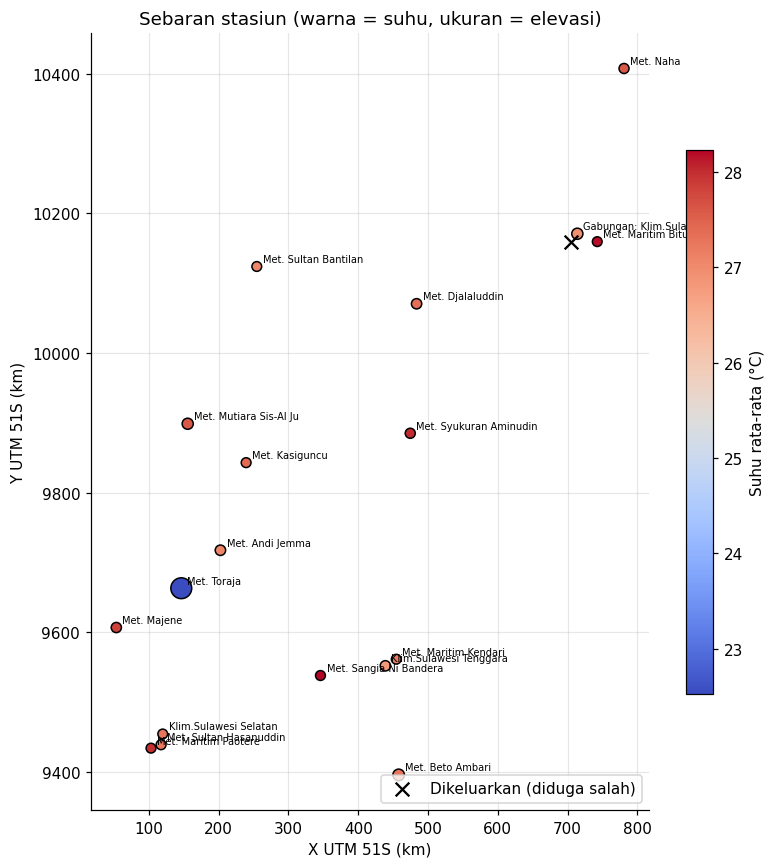

In [11]:
dropped = df_all[df_all.Station_ID.isin(DROP_IDS)]
fig, ax = plt.subplots(figsize=(7.5, 8))
sc = ax.scatter(dfa.X, dfa.Y, c=dfa.Tavg, s=40 + dfa.Elev / 6, cmap="coolwarm", edgecolor="k", zorder=3)
if len(dropped): ax.scatter(dropped.X, dropped.Y, marker="x", c="k", s=80, zorder=4, label="Dikeluarkan (diduga salah)")
for _, r in dfa.iterrows():
    ax.annotate(r.Nama.replace("Stasiun ", "").replace("Meteorologi ", "Met. ").replace("Klimatologi ", "Klim.")[:22], (r.X, r.Y), fontsize=6.5, xytext=(4, 3), textcoords="offset points")
ax.set_aspect("equal"); ax.set_xlabel("X UTM 51S (km)"); ax.set_ylabel("Y UTM 51S (km)")
ax.set_title("Sebaran stasiun (warna = suhu, ukuran = elevasi)")
plt.colorbar(sc, ax=ax, shrink=.7, label="Suhu rata-rata (°C)");
if len(dropped): ax.legend(loc="lower right")
plt.tight_layout(); plt.savefig("hasil/01_sebaran_stasiun.png", dpi=200); plt.show()

Stasiun tersebar di seluruh pulau, tetapi **jaraknya jarang dan tidak merata**: ada kelompok rapat (Makassar, Manado, Kendari) dan bentangan kosong yang lebar di pedalaman. Ini membatasi seberapa jauh struktur spasial bisa dipelajari dari data.

### 4.2 Statistik deskriptif dan sebaran nilai

      count    mean  median      std    min     max   skew    kurt    CV_%
Tavg   18.0  27.194   27.32    1.240  22.53   28.23 -3.403  13.278    4.56
Elev   18.0  75.056   19.00  202.598   1.00  878.00  4.093  17.080  269.93
Shapiro-Wilk Tavg: W=0.584, p=0.0000 -> tidak normal
Shapiro-Wilk Elev: W=0.368, p=0.0000 -> tidak normal


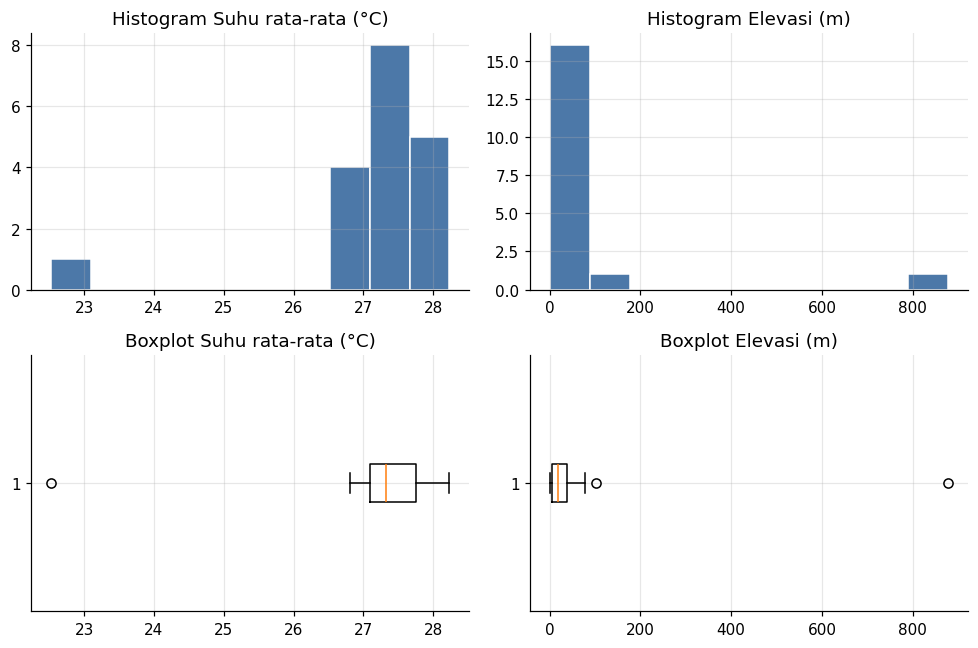

In [12]:
desc = dfa[["Tavg", "Elev"]].agg(["count", "mean", "median", "std", "min", "max", "skew", "kurt"]).T
desc["CV_%"] = desc["std"] / desc["mean"] * 100
print(desc.round(3))
for c in ["Tavg", "Elev"]:
    w, p = stats.shapiro(dfa[c]); print(f"Shapiro-Wilk {c}: W={w:.3f}, p={p:.4f} -> {'tidak normal' if p<0.05 else 'tidak ditolak normal'}")

fig, ax = plt.subplots(2, 2, figsize=(9, 6))
for k, (c, lab) in enumerate([("Tavg", "Suhu rata-rata (°C)"), ("Elev", "Elevasi (m)")]):
    ax[0, k].hist(dfa[c], bins=10, color="#4c78a8", edgecolor="w"); ax[0, k].set_title(f"Histogram {lab}")
    ax[1, k].boxplot(dfa[c], vert=False); ax[1, k].set_title(f"Boxplot {lab}")
plt.tight_layout(); plt.savefig("hasil/02_distribusi.png", dpi=200); plt.show()

**Membaca hasilnya.**

* **Suhu** berkisar sempit pada sebagian besar stasiun (sekitar 26,8 sampai 28,2 °C) dengan satu nilai rendah (Toraja), sehingga distribusinya miring ke kiri.
* **Elevasi sangat miring ke kanan** (*skewness* besar): hampir semua stasiun di pesisir (di bawah 110 m) dan hanya satu di 878 m. Uji Shapiro-Wilk menolak normalitas untuk **kedua** variabel, dan penyebabnya sama: satu stasiun dataran tinggi.
* Ko-kriging tidak mewajibkan distribusi normal, tetapi distribusi timpang seperti ini berarti **satu titik menentukan sebagian besar variasi**. Transformasi log tidak dipakai karena hubungan fisik suhu terhadap ketinggian pada dasarnya linear (sekitar 6 °C per km).

### 4.3 Korelasi suhu dan elevasi

Ko-kriging hanya bermanfaat kalau variabel sekunder berkorelasi dengan variabel primer.

Pearson r      = -0.943  (p = 4.75e-09)   R2 = 0.889
Spearman rho   = -0.328  (p = 1.84e-01)
Kemiringan     = -5.77 °C per km  (95% CI: -6.85 s.d. -4.69)
Intersep       = 27.63 °C (perkiraan suhu di permukaan laut)

Uji ketahanan tanpa stasiun > 500 m (n = 17): Pearson r = -0.284 (p = 0.269), Spearman = -0.201 (p = 0.438)


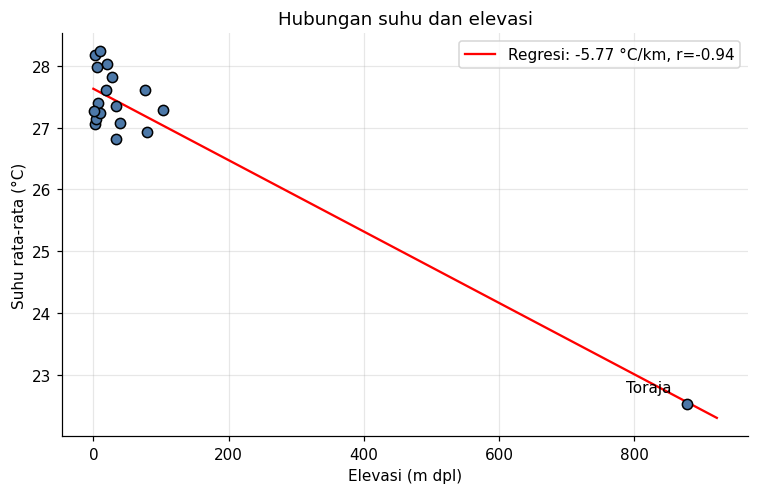

In [13]:
E, T = dfa.Elev.values, dfa.Tavg.values
lr = stats.linregress(E, T)
rho, p_s = stats.spearmanr(E, T)
ci = stats.t.ppf(0.975, len(E) - 2) * lr.stderr
print(f"Pearson r      = {lr.rvalue:.3f}  (p = {lr.pvalue:.2e})   R2 = {lr.rvalue**2:.3f}")
print(f"Spearman rho   = {rho:.3f}  (p = {p_s:.2e})")
print(f"Kemiringan     = {lr.slope*1000:.2f} °C per km  (95% CI: {(lr.slope-ci)*1000:.2f} s.d. {(lr.slope+ci)*1000:.2f})")
print(f"Intersep       = {lr.intercept:.2f} °C (perkiraan suhu di permukaan laut)")

# Uji ketahanan: tanpa stasiun dataran tinggi
low = E < 500
lr2 = stats.linregress(E[low], T[low]); rho2, p2 = stats.spearmanr(E[low], T[low])
print(f"\nUji ketahanan tanpa stasiun > 500 m (n = {low.sum()}): Pearson r = {lr2.rvalue:.3f} (p = {lr2.pvalue:.3f}), Spearman = {rho2:.3f} (p = {p2:.3f})")

fig, ax = plt.subplots(figsize=(7, 4.6))
ax.scatter(E, T, s=45, c="#4c78a8", edgecolor="k", zorder=3)
xs = np.linspace(0, E.max() * 1.05, 50); ax.plot(xs, lr.intercept + lr.slope * xs, "r-", label=f"Regresi: {lr.slope*1000:.2f} °C/km, r={lr.rvalue:.2f}")
for _, r in dfa[dfa.Elev > 500].iterrows(): ax.annotate("Toraja", (r.Elev, r.Tavg), xytext=(-40, 8), textcoords="offset points")
ax.set_xlabel("Elevasi (m dpl)"); ax.set_ylabel("Suhu rata-rata (°C)"); ax.set_title("Hubungan suhu dan elevasi"); ax.legend()
plt.tight_layout(); plt.savefig("hasil/03_scatter_suhu_elevasi.png", dpi=200); plt.show()

**Membaca hasilnya.**

* Korelasi **Pearson** sangat kuat dan negatif, dan kemiringannya (sekitar 5,8 °C per km) sangat dekat dengan laju penurunan suhu atmosfer yang dikenal (sekitar 6 sampai 6,5 °C per km). Ini bukti bahwa data setelah Manado dikeluarkan masuk akal secara fisik.
* **Tetapi baca dua angka lainnya dengan teliti.** Korelasi peringkat **Spearman** jauh lebih lemah dan tidak signifikan, dan tanpa stasiun dataran tinggi korelasi Pearson ikut merosot dan tidak signifikan. Artinya kekuatan hubungan hampir seluruhnya bersumber dari **satu titik**, Toraja, melawan stasiun pesisir. Ini bukan cacat data, tetapi **keterbatasan yang wajib disebut di laporan**.
* Untuk ko-kriging, syarat "variabel sekunder berkorelasi dengan primer" terpenuhi secara formal, tetapi kekokohannya rendah.

## 5. Variogram eksperimental

### 5.1 Konsep

Semivariogram mengukur seberapa berbeda dua titik seiring bertambahnya jarak $h$:

$$\hat\gamma_{11}(h)=\frac{1}{2N(h)}\sum_{i=1}^{N(h)}\big[z_1(x_i)-z_1(x_i+h)\big]^2$$

Ko-kriging membutuhkan tiga fungsi: variogram langsung suhu $\gamma_{11}$, variogram langsung elevasi $\gamma_{22}$, dan **variogram silang** $\gamma_{12}$:

$$\hat\gamma_{12}(h)=\frac{1}{2N(h)}\sum_{i=1}^{N(h)}\big[z_1(x_i)-z_1(x_i+h)\big]\big[z_2(x_i)-z_2(x_i+h)\big]$$

Nilai $\gamma_{12}$ negatif berarti kedua variabel berlawanan arah (elevasi naik, suhu turun). Jarak maksimum (*cutoff*) diambil setengah jarak terjauh antar stasiun, aturan praktis yang umum dipakai supaya jumlah pasangan di tiap lag cukup.

In [14]:
def emp_variograms(xy, Z, bins):
    # Variogram langsung (g11, g22) dan silang (g12). Z berukuran (n, 2).
    n = len(xy); iu = np.triu_indices(n, 1)
    d = cdist(xy, xy)[iu]
    d1 = (Z[:, 0][:, None] - Z[:, 0][None, :])[iu]; d2 = (Z[:, 1][:, None] - Z[:, 1][None, :])[iu]
    out = {"h": [], "n": [], "g11": [], "g22": [], "g12": []}
    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (d >= lo) & (d < hi)
        if m.sum() == 0: continue
        out["h"].append(d[m].mean()); out["n"].append(int(m.sum()))
        out["g11"].append(0.5 * np.mean(d1[m] ** 2)); out["g22"].append(0.5 * np.mean(d2[m] ** 2))
        out["g12"].append(0.5 * np.mean(d1[m] * d2[m]))
    return {k: np.array(v) for k, v in out.items()}

xy = dfa[["X", "Y"]].values; Z = dfa[["Tavg", "Elev"]].values; n = len(dfa)
maxd = cdist(xy, xy).max(); cutoff = maxd / 2
bins = np.linspace(0, cutoff, N_LAGS + 1)
ev = emp_variograms(xy, Z, bins)
print(f"Jarak terjauh antar stasiun = {maxd:.0f} km | cutoff = {cutoff:.0f} km | lebar lag = {cutoff/N_LAGS:.0f} km")
pd.DataFrame(ev).round(3).rename(columns={"h": "jarak_rata2_km", "n": "jumlah_pasangan"})

Jarak terjauh antar stasiun = 1187 km | cutoff = 593 km | lebar lag = 85 km


,jarak_rata2_km,jumlah_pasangan,g11,g22,g12
0,30.730,6,1.954,59221.667,-326.898
1,129.395,8,1.986,46526.188,-277.941
2,220.604,21,3.895,106264.595,-627.362
3,306.437,21,1.117,35541.500,-184.754
4,377.718,23,1.287,30083.109,-186.706
5,465.392,15,0.809,27205.800,-133.016
6,557.974,11,1.265,32846.136,-185.381


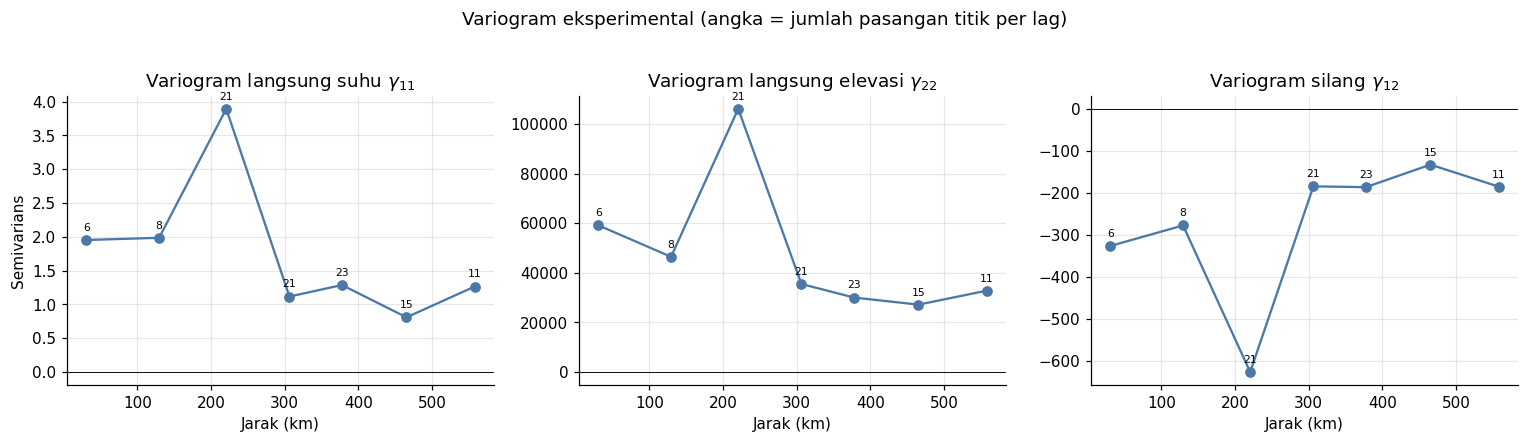

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.9))
for a, (k, ttl) in zip(ax, [("g11", r"Variogram langsung suhu $\gamma_{11}$"), ("g22", r"Variogram langsung elevasi $\gamma_{22}$"), ("g12", r"Variogram silang $\gamma_{12}$")]):
    a.plot(ev["h"], ev[k], "o-", color="#4c78a8")
    for hh, gg, nn in zip(ev["h"], ev[k], ev["n"]): a.annotate(str(nn), (hh, gg), xytext=(0, 6), textcoords="offset points", ha="center", fontsize=7)
    a.set_title(ttl); a.set_xlabel("Jarak (km)"); a.axhline(0, color="k", lw=.6)
ax[0].set_ylabel("Semivarians")
fig.suptitle("Variogram eksperimental (angka = jumlah pasangan titik per lag)", y=1.02)
plt.tight_layout(); plt.savefig("hasil/04_variogram_eksperimental.png", dpi=200, bbox_inches="tight"); plt.show()

### 5.2 Membaca variogram

* $\gamma_{11}$ (suhu) **hampir datar**, tidak naik jelas seiring jarak. Artinya suhu di dua stasiun yang berjauhan tidak lebih berbeda daripada dua stasiun yang berdekatan. Sebabnya wajar: stasiun pesisir semuanya berada di sekitar 27 sampai 28 °C, sehingga variasi suhu ditentukan oleh **ketinggian**, bukan oleh **jarak**.
* $\gamma_{22}$ dan $\gamma_{12}$ ikut tidak beraturan karena variasi elevasi didominasi satu stasiun (Toraja). Lag yang memuat pasangan dengan Toraja melonjak, lag lain rendah.
* Angka di atas titik menunjukkan jumlah pasangan. Lag dengan pasangan sedikit (biasanya < 10) kurang bisa diandalkan.

Kesimpulannya, struktur spasial **berbasis jarak** yang lemah, sedangkan hubungan **suhu-elevasi di lokasi yang sama** (*collocated*) sangat kuat. Ini sangat menentukan bagaimana model dan hasil ko-kriging ditafsirkan di bagian berikut.

## 6. Pemodelan variogram: Linear Model of Coregionalization (LMC)

Ko-kriging tidak bisa memakai tiga variogram yang dicocokkan sendiri-sendiri, karena matriks kovarians gabungan harus **semi-definit positif** (kalau tidak, varians prediksi bisa negatif). LMC menjamin itu dengan satu struktur bersama:

$$\gamma_{ij}(h)=N_{ij}+B_{ij}\,S(h;a),\qquad i,j\in\{1,2\}$$

* $S(h;a)$: model variogram baku dengan sill 1 dan *range* $a$ (bola/*spherical*, eksponensial, atau Gauss).
* $\mathbf{B}=[B_{ij}]$: matriks *sill* terkoregionalisasi. $\mathbf{N}=[N_{ij}]$: matriks *nugget*.
* $\mathbf{B}$ dan $\mathbf{N}$ dipaksa semi-definit positif lewat parameterisasi $\mathbf{B}=\mathbf{L}\mathbf{L}^\top$ (Cholesky).

Parameter dicari dengan **kuadrat terkecil berbobot** (bobot $\propto\sqrt{N(h)}$), dari 30 titik awal acak (tetap, ada `RNG_SEED`) agar tidak terjebak minimum lokal. Variabel diskalakan agar suhu ($\sim$°C²) dan elevasi ($\sim$m²) berkontribusi sepadan.

In [16]:
def unit_model(h, a, kind):
    # Model variogram baku (sill = 1, range = a)
    h = np.asarray(h, float); r = h / a
    if kind == "spherical":   return np.where(h < a, 1.5 * r - 0.5 * r ** 3, 1.0)
    if kind == "exponential": return 1 - np.exp(-3 * r)
    if kind == "gaussian":    return 1 - np.exp(-3 * r ** 2)
    raise ValueError(kind)

def _psd(p):
    L = np.array([[p[0], 0.0], [p[1], p[2]]]); return L @ L.T

def fit_lmc(ev, kind, a0, a_bounds, n_starts=30, seed=RNG_SEED):
    h, npair = ev["h"], ev["n"]
    Y = np.vstack([ev["g11"], ev["g22"], ev["g12"]])
    s1, s2 = np.sqrt(ev["g11"].max()), np.sqrt(ev["g22"].max())
    scale = np.array([s1 ** 2, s2 ** 2, s1 * s2])[:, None]; w = np.sqrt(npair)[None, :]
    def model(p):
        S = unit_model(h, p[0], kind); B, N = _psd(p[1:4]), _psd(p[4:7])
        return np.vstack([N[0, 0] + B[0, 0] * S, N[1, 1] + B[1, 1] * S, N[0, 1] + B[0, 1] * S])
    def res(p): return ((model(p) - Y) / scale * w).ravel()
    rng = np.random.default_rng(seed); best = None
    lb = np.r_[a_bounds[0], -np.inf * np.ones(6)]; ub = np.r_[a_bounds[1], np.inf * np.ones(6)]
    for _ in range(n_starts):
        p0 = np.r_[a0 * rng.uniform(.5, 1.5), s1 * rng.uniform(.3, 1), s2 * rng.uniform(-.5, .5), s2 * rng.uniform(.3, 1),
                   s1 * rng.uniform(.05, .4), 0.0, s2 * rng.uniform(.05, .4)]
        try: r = least_squares(res, p0, bounds=(lb, ub))
        except Exception: continue
        if best is None or r.cost < best.cost: best = r
    p = best.x
    return {"kind": kind, "a": float(p[0]), "B": _psd(p[1:4]), "N": _psd(p[4:7]), "wsse": float(2 * best.cost)}

def fit_univariate(ev, kind, a_bounds):
    # Model variogram tunggal untuk suhu (dipakai Ordinary Kriging sebagai pembanding)
    h, g, nn = ev["h"], ev["g11"], ev["n"]; best = None
    for a in np.linspace(a_bounds[0], a_bounds[1], 12):
        f = lambda p: (p[1] + p[0] * unit_model(h, a, kind) - g) / g.max() * np.sqrt(nn)
        r = least_squares(f, [g.max() * .7, g.max() * .1], bounds=([0, 0], [np.inf, np.inf]))
        if best is None or r.cost < best[0].cost: best = (r, a)
    r, a = best; return {"kind": kind, "a": float(a), "b": float(r.x[0]), "nug": float(r.x[1])}

a_bounds = (cutoff * .1, maxd)
fits = {k: fit_lmc(ev, k, cutoff * .6, a_bounds) for k in ["spherical", "exponential", "gaussian"]}
tab = pd.DataFrame([{"model": k, "range_km": f["a"], "WSSE": f["wsse"], "B11 (sill suhu)": f["B"][0, 0], "B22 (sill elevasi)": f["B"][1, 1],
                     "B12": f["B"][0, 1], "N11 (nugget suhu)": f["N"][0, 0], "N22": f["N"][1, 1], "N12": f["N"][0, 1]} for k, f in fits.items()]).set_index("model")
print(tab.round(3).T)
kind_sel = min(fits, key=lambda k: fits[k]["wsse"]) if MODEL_KIND == "auto" else MODEL_KIND
lmc = fits[kind_sel]; uni = fit_univariate(ev, kind_sel, a_bounds)
print(f"\nModel dipakai: {kind_sel.upper()} (dipilih {'otomatis: WSSE terkecil' if MODEL_KIND=='auto' else 'manual'})")

model               spherical  exponential   gaussian
range_km               59.343       59.343     59.343
WSSE                   24.552       24.552     24.552
B11 (sill suhu)         0.001        0.001      0.001
B22 (sill elevasi)     28.971       37.524     17.447
B12                     0.179        0.121      0.131
N11 (nugget suhu)       1.794        1.795      1.794
N22                 49171.622    49165.042  49169.551
N12                  -281.838     -281.781   -281.957

Model dipakai: SPHERICAL (dipilih otomatis: WSSE terkecil)


Rasio nugget / sill total (suhu) = 99.9%   [< 25% ketergantungan spasial kuat | 25-75% sedang | > 75% lemah]
Range hasil fitting = 59.3 km (batas bawah pencarian = 59.3 km) -> menempel di batas bawah
Selisih WSSE antar tiga model = 0.0000
CATATAN: struktur berbasis jarak pada suhu praktis tidak ada (efek nugget murni). Pilihan jenis model tidak berpengaruh nyata.
Matriks B (struktur): nilai eigen = [ 0.     28.9723]  -> semi-definit positif: True | korelasi silang = 1.000
Matriks N (nugget): nilai eigen = [1.78700000e-01 4.91732373e+04]  -> semi-definit positif: True | korelasi silang = -0.949


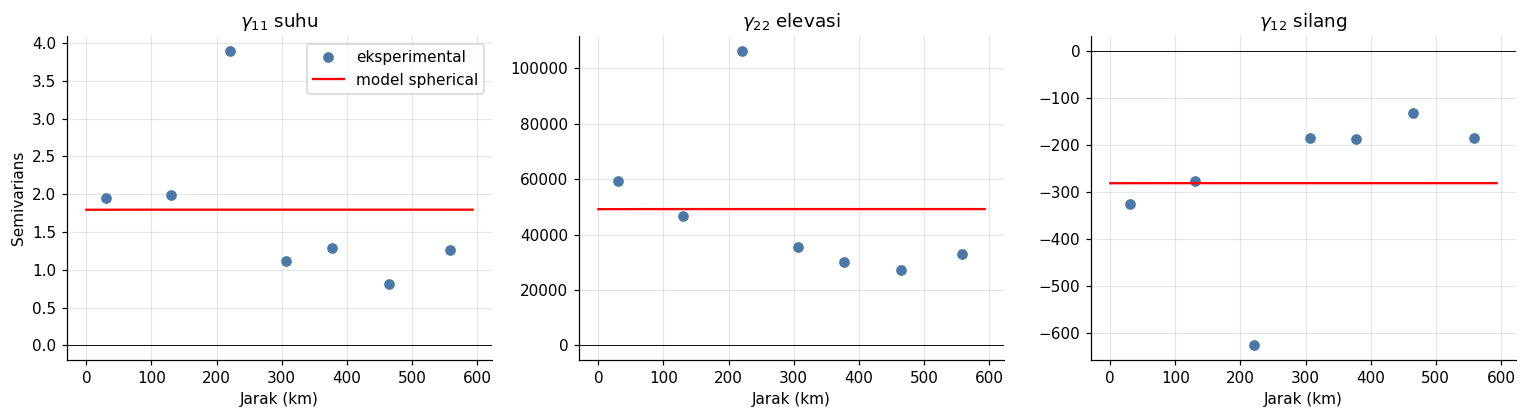

In [17]:
# Diagnostik kekuatan struktur spasial suhu
ratio = lmc["N"][0, 0] / (lmc["N"][0, 0] + lmc["B"][0, 0])
at_bound = lmc["a"] <= a_bounds[0] * 1.001
print(f"Rasio nugget / sill total (suhu) = {ratio*100:.1f}%   [< 25% ketergantungan spasial kuat | 25-75% sedang | > 75% lemah]")
print(f"Range hasil fitting = {lmc['a']:.1f} km (batas bawah pencarian = {a_bounds[0]:.1f} km) -> {'menempel di batas bawah' if at_bound else 'di dalam rentang pencarian'}")
print(f"Selisih WSSE antar tiga model = {tab['WSSE'].max() - tab['WSSE'].min():.4f}")
if ratio > .75:
    print("CATATAN: struktur berbasis jarak pada suhu praktis tidak ada (efek nugget murni). Pilihan jenis model tidak berpengaruh nyata.")

# Pemeriksaan sifat semi-definit positif dan koefisien korelasi terkoregionalisasi
for nm, M in [("B (struktur)", lmc["B"]), ("N (nugget)", lmc["N"])]:
    eig = np.linalg.eigvalsh(M)
    rho = M[0, 1] / np.sqrt(M[0, 0] * M[1, 1]) if M[0, 0] > 1e-9 and M[1, 1] > 1e-9 else np.nan
    print(f"Matriks {nm}: nilai eigen = {eig.round(4)}  -> semi-definit positif: {bool((eig >= -1e-9).all())} | korelasi silang = {rho:.3f}")

hh = np.linspace(0.01, cutoff, 200); S = unit_model(hh, lmc["a"], lmc["kind"])
fig, ax = plt.subplots(1, 3, figsize=(14, 3.9))
for a, (k, i, j, ttl) in zip(ax, [("g11", 0, 0, r"$\gamma_{11}$ suhu"), ("g22", 1, 1, r"$\gamma_{22}$ elevasi"), ("g12", 0, 1, r"$\gamma_{12}$ silang")]):
    a.plot(ev["h"], ev[k], "o", color="#4c78a8", label="eksperimental")
    a.plot(hh, lmc["N"][i, j] + lmc["B"][i, j] * S, "r-", label=f"model {lmc['kind']}")
    a.set_title(ttl); a.set_xlabel("Jarak (km)"); a.axhline(0, color="k", lw=.6)
ax[0].legend(); ax[0].set_ylabel("Semivarians")
plt.tight_layout(); plt.savefig("hasil/05_model_LMC.png", dpi=200, bbox_inches="tight"); plt.show()

### 6.1 Menafsirkan parameter

* **Pada data ini ketiga model (bola, eksponensial, Gauss) menghasilkan parameter yang praktis identik.** Nugget suhu ($N_{11}$) menyerap hampir seluruh variasi, sill struktur ($B_{11}$) mendekati nol, dan *range* menempel pada batas bawah pencarian. Artinya, untuk suhu model efektifnya adalah **efek nugget murni**: tidak ada ketergantungan spasial berbasis jarak yang dapat dipelajari dari 18 stasiun ini. Karena itu pemilihan model "otomatis" tidak bermakna (skornya sama) dan nilai *range* **tidak boleh ditafsirkan secara fisik**.
* Ini bukan kesalahan kode. Penyebabnya masuk akal: suhu stasiun pesisir semuanya berkisar 27 sampai 28 °C tanpa pola jarak, dan satu-satunya variasi besar datang dari elevasi (Toraja).
* **Korelasi silang pada nugget** mendekati $-1$ (lihat cetakan di atas). Pada skala lokal, suhu dan elevasi berlawanan arah hampir sempurna. Inilah komponen yang membawa informasi elevasi ke dalam prediksi ko-kriging. Korelasi silang $=1{,}000$ pada matriks $\mathbf B$ hanyalah artefak matriks berpangkat 1 dengan sill mendekati nol, bukan temuan.
* Semua nilai eigen $\ge 0$: model LMC sah (semi-definit positif).
* Uji sensitivitas di Bagian 8.5 memeriksa apakah kesimpulan prediksi berubah saat model dan jumlah lag digeser.

## 7. Sistem persamaan Ordinary Co-Kriging

Prediksi suhu di titik $x_0$ adalah kombinasi linear suhu **dan** elevasi di stasiun:

$$\hat z_1(x_0)=\sum_{i=1}^{n_1}\lambda^{(1)}_i\,z_1(x_i)+\sum_{j=1}^{n_2}\lambda^{(2)}_j\,z_2(x_j)$$

Kendala ketakbiasan (Ordinary Co-Kriging): $\sum_i\lambda^{(1)}_i=1$ dan $\sum_j\lambda^{(2)}_j=0$. Bobot diperoleh dari sistem:

$$
\begin{bmatrix}\mathbf C_{11}&\mathbf C_{12}&\mathbf 1&\mathbf 0\\ \mathbf C_{21}&\mathbf C_{22}&\mathbf 0&\mathbf 1\\ \mathbf 1^\top&\mathbf 0&0&0\\ \mathbf 0&\mathbf 1^\top&0&0\end{bmatrix}
\begin{bmatrix}\boldsymbol\lambda^{(1)}\\ \boldsymbol\lambda^{(2)}\\ \mu_1\\ \mu_2\end{bmatrix}=
\begin{bmatrix}\mathbf c_{10}\\ \mathbf c_{20}\\ 1\\ 0\end{bmatrix}
$$

dengan kovarians $C_{ij}(h)=B_{ij}\,[1-S(h)]$ untuk $h>0$, dan $C_{ij}(0)=B_{ij}+N_{ij}$ untuk $h=0$. Nugget silang $N_{12}$ ikut berlaku hanya bila suhu dan elevasi berada di lokasi yang sama (kolokasi). Varians kriging:

$$\sigma^2_{CK}(x_0)=C_{11}(0)-\boldsymbol\lambda^{(1)\top}\mathbf c_{10}-\boldsymbol\lambda^{(2)\top}\mathbf c_{20}-\mu_1$$

**Poin kunci: elevasi di titik yang diprediksi.** Elevasi bisa diketahui di lokasi mana pun dari DEM/SRTM. Maka saat memprediksi suhu di $x_0$, elevasi di $x_0$ ikut dimasukkan sebagai data sekunder (*collocated co-kriging*). Inilah manfaat nyata ko-kriging pada data ini, dan efeknya dibuktikan pada validasi silang (Bagian 8).

Pembanding yang dipakai:

* **Ordinary Kriging (OK)**: hanya memakai suhu, tanpa elevasi.
* **Regresi linear** suhu terhadap elevasi (tanpa struktur spasial).

In [18]:
def cov_cross(model, dist, i, j):
    # Kovarians untuk h > 0: B_ij * (1 - S(h)). Nugget ditambahkan terpisah pada h = 0.
    return model["B"][i, j] * (1 - unit_model(dist, model["a"], model["kind"]))

def cokrige_point(x0, P_xy, P_z, S_xy, S_z, model):
    # Ordinary co-kriging di satu titik.
    # P_*: data primer (suhu), S_*: data sekunder (elevasi), keduanya boleh berlokasi berbeda.
    n1, n2 = len(P_xy), len(S_xy); N = model["N"]
    C11 = cov_cross(model, cdist(P_xy, P_xy), 0, 0) + np.eye(n1) * N[0, 0]
    C22 = cov_cross(model, cdist(S_xy, S_xy), 1, 1) + np.eye(n2) * N[1, 1]
    D12 = cdist(P_xy, S_xy); C12 = cov_cross(model, D12, 0, 1) + (D12 < 1e-9) * N[0, 1]
    c10 = cov_cross(model, cdist(P_xy, x0[None])[:, 0], 0, 0)
    D20 = cdist(S_xy, x0[None])[:, 0]; c20 = cov_cross(model, D20, 0, 1) + (D20 < 1e-9) * N[0, 1]
    m = n1 + n2 + 2; A = np.zeros((m, m))
    A[:n1, :n1] = C11; A[:n1, n1:n1 + n2] = C12; A[n1:n1 + n2, :n1] = C12.T; A[n1:n1 + n2, n1:n1 + n2] = C22
    A[:n1, n1 + n2] = 1; A[n1 + n2, :n1] = 1; A[n1:n1 + n2, n1 + n2 + 1] = 1; A[n1 + n2 + 1, n1:n1 + n2] = 1
    sol = np.linalg.solve(A, np.r_[c10, c20, 1.0, 0.0])
    l1, l2, mu1 = sol[:n1], sol[n1:n1 + n2], sol[n1 + n2]
    pred = l1 @ P_z + l2 @ S_z
    var = (model["B"][0, 0] + N[0, 0]) - l1 @ c10 - l2 @ c20 - mu1
    return float(pred), float(max(var, 0.0))

def ordinary_kriging_point(x0, P_xy, P_z, um):
    n = len(P_xy); a, kind, b, nug = um["a"], um["kind"], um["b"], um["nug"]
    C = b * (1 - unit_model(cdist(P_xy, P_xy), a, kind)) + np.eye(n) * nug
    c0 = b * (1 - unit_model(cdist(P_xy, x0[None])[:, 0], a, kind))
    A = np.zeros((n + 1, n + 1)); A[:n, :n] = C; A[:n, n] = 1; A[n, :n] = 1
    s = np.linalg.solve(A, np.r_[c0, 1.0])
    return float(s[:n] @ P_z), float(max(b + nug - s[:n] @ c0 - s[n], 0.0))

def predict_cok(x0, P_xy, P_z, S_xy, S_z, model, elev_at_target=None):
    # Jika elevasi di titik target diketahui (mis. dari DEM), masukkan sebagai data sekunder kolokasi.
    if elev_at_target is not None:
        S_xy = np.vstack([S_xy, x0[None]]); S_z = np.r_[S_z, elev_at_target]
    return cokrige_point(x0, P_xy, P_z, S_xy, S_z, model)

# Uji kebenaran implementasi: bila korelasi silang dinolkan, ko-kriging harus identik dengan Ordinary Kriging
m0 = {"kind": lmc["kind"], "a": uni["a"], "B": np.array([[uni["b"], 0.0], [0.0, 1.0]]), "N": np.array([[uni["nug"], 0.0], [0.0, 1.0]])}
x_test = xy.mean(axis=0)
ck = cokrige_point(x_test, xy, Z[:, 0], xy, Z[:, 1], m0); ok_ = ordinary_kriging_point(x_test, xy, Z[:, 0], uni)
print(f"Uji sanity  CK (silang=0): pred={ck[0]:.6f}, var={ck[1]:.6f}")
print(f"            OK           : pred={ok_[0]:.6f}, var={ok_[1]:.6f}")
assert abs(ck[0] - ok_[0]) < 1e-6 and abs(ck[1] - ok_[1]) < 1e-6, "Implementasi tidak konsisten"
print("Implementasi konsisten.")

Uji sanity  CK (silang=0): pred=27.194167, var=1.895123
            OK           : pred=27.194167, var=1.895123
Implementasi konsisten.


## 8. Validasi silang *leave-one-out* dan perhitungan R²

### 8.1 Cara kerja dan metrik

Setiap stasiun bergantian **dikeluarkan**, suhunya diprediksi dari stasiun lain, lalu dibandingkan dengan nilai sebenarnya. Elevasi stasiun yang dikeluarkan tetap dianggap diketahui (seperti elevasi dari DEM di lokasi tak bersampel).

| Metrik | Rumus | Arti |
|---|---|---|
| **R²<sub>CV</sub>** | $1-\dfrac{\sum(z_i-\hat z_i)^2}{\sum(z_i-\bar z)^2}$ | Berapa persen variasi suhu yang berhasil diprediksi. Bisa **negatif** kalau prediksi lebih buruk daripada sekadar memakai rata-rata. **Ini metrik utama.** |
| $r^2$ (Pearson) | $\mathrm{corr}(z,\hat z)^2$ | Hanya mengukur keselarasan pola, mengabaikan bias, jadi cenderung lebih optimistis. |
| RMSE, MAE | | Galat dalam satuan °C. |
| ME | $\overline{\hat z-z}$ | Bias rata-rata, idealnya mendekati 0. |
| MSDR | $\overline{(\hat z-z)^2/\sigma^2_{CK}}$ | Kalibrasi varians kriging, idealnya mendekati 1. |

Ada dua skema. **Skema A** memakai parameter variogram yang dicocokkan dari seluruh stasiun (praktik baku pada banyak perangkat lunak). **Skema B** (lebih ketat) mencocokkan ulang variogram **di dalam setiap lipatan** tanpa stasiun yang sedang diuji sehingga tidak ada kebocoran informasi.

In [19]:
def cv_metrics(obs, pred, var=None):
    obs, pred = np.asarray(obs, float), np.asarray(pred, float); e = pred - obs
    sse, sst = (e ** 2).sum(), ((obs - obs.mean()) ** 2).sum()
    out = {"R2_CV": 1 - sse / sst, "r2_Pearson": np.corrcoef(obs, pred)[0, 1] ** 2,
           "RMSE": np.sqrt(np.mean(e ** 2)), "MAE": np.abs(e).mean(), "ME": e.mean()}
    if var is not None: out["MSDR"] = float(np.mean(e ** 2 / np.maximum(var, 1e-9)))
    return out

def loo_fixed(xy, Z, lmc, uni, secondary_at_target=True):
    n = len(xy); pred = {k: np.zeros(n) for k in ["OK", "COK", "REG"]}; var = {k: np.zeros(n) for k in ["OK", "COK"]}
    for i in range(n):
        m = np.arange(n) != i
        pred["OK"][i], var["OK"][i] = ordinary_kriging_point(xy[i], xy[m], Z[m, 0], uni)
        e_t = Z[i, 1] if secondary_at_target else None
        pred["COK"][i], var["COK"][i] = predict_cok(xy[i], xy[m], Z[m, 0], xy[m], Z[m, 1], lmc, e_t)
        r = stats.linregress(Z[m, 1], Z[m, 0]); pred["REG"][i] = r.intercept + r.slope * Z[i, 1]
    return pred, var

def loo_nested(xy, Z, kind, n_lags, n_starts=8):
    n = len(xy); pred = {k: np.zeros(n) for k in ["OK", "COK", "REG"]}; var = {k: np.zeros(n) for k in ["OK", "COK"]}
    for i in range(n):
        m = np.arange(n) != i; xm, Zm = xy[m], Z[m]
        md_ = cdist(xm, xm).max(); ct = md_ / 2; ev_m = emp_variograms(xm, Zm, np.linspace(0, ct, n_lags + 1))
        lmc_m = fit_lmc(ev_m, kind, ct * .6, (ct * .1, md_), n_starts=n_starts); uni_m = fit_univariate(ev_m, kind, (ct * .1, md_))
        pred["OK"][i], var["OK"][i] = ordinary_kriging_point(xy[i], xm, Zm[:, 0], uni_m)
        pred["COK"][i], var["COK"][i] = predict_cok(xy[i], xm, Zm[:, 0], xm, Zm[:, 1], lmc_m, Z[i, 1])
        r = stats.linregress(Zm[:, 1], Zm[:, 0]); pred["REG"][i] = r.intercept + r.slope * Z[i, 1]
    return pred, var

def metrics_table(obs, pred, var):
    rows = {"Ordinary Kriging (suhu saja)": cv_metrics(obs, pred["OK"], var["OK"]),
            "Ordinary Co-Kriging (suhu + elevasi)": cv_metrics(obs, pred["COK"], var["COK"]),
            "Regresi linear suhu ~ elevasi": cv_metrics(obs, pred["REG"])}
    return pd.DataFrame(rows).T

obs = Z[:, 0]

### 8.2 Skema A: parameter variogram tetap

In [20]:
predA, varA = loo_fixed(xy, Z, lmc, uni)
tabA = metrics_table(obs, predA, varA)
print(f"Validasi silang Skema A (n = {len(obs)} stasiun, model {lmc['kind']})"); tabA.round(3)

Validasi silang Skema A (n = 18 stasiun, model spherical)


,R2_CV,r2_Pearson,RMSE,MAE,ME,MSDR
Ordinary Kriging (suhu saja),-0.121,1.000,1.276,0.661,-0.00,0.856
Ordinary Co-Kriging (suhu + elevasi),0.876,0.876,0.424,0.380,-0.00,0.931
Regresi linear suhu ~ elevasi,0.791,0.860,0.551,0.461,0.08,NaN


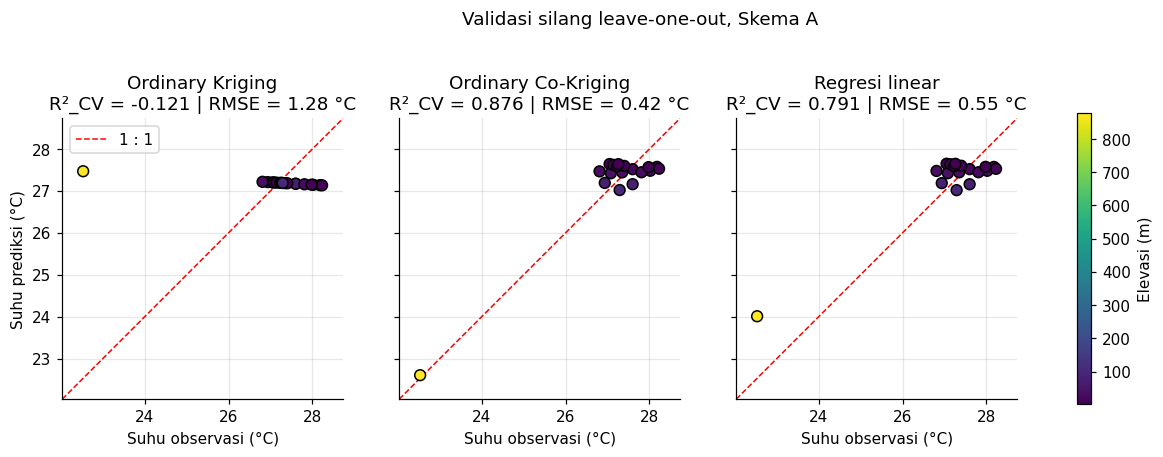

In [21]:
def plot_cv(pred, ttl, fname):
    fig, ax = plt.subplots(1, 3, figsize=(14, 4.3), sharex=True, sharey=True)
    lim = [obs.min() - .5, obs.max() + .5]
    for a, (k, nm) in zip(ax, [("OK", "Ordinary Kriging"), ("COK", "Ordinary Co-Kriging"), ("REG", "Regresi linear")]):
        m = cv_metrics(obs, pred[k])
        a.scatter(obs, pred[k], c=dfa.Elev, cmap="viridis", s=50, edgecolor="k", zorder=3)
        a.plot(lim, lim, "r--", lw=1, label="1 : 1"); a.set_xlim(lim); a.set_ylim(lim); a.set_aspect("equal")
        a.set_title(f"{nm}\nR²_CV = {m['R2_CV']:.3f} | RMSE = {m['RMSE']:.2f} °C"); a.set_xlabel("Suhu observasi (°C)")
    ax[0].set_ylabel("Suhu prediksi (°C)"); ax[0].legend(loc="upper left")
    sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(dfa.Elev.min(), dfa.Elev.max()))
    fig.colorbar(sm, ax=ax, shrink=.8, label="Elevasi (m)"); fig.suptitle(ttl, y=1.02)
    plt.savefig(fname, dpi=200, bbox_inches="tight"); plt.show()

plot_cv(predA, "Validasi silang leave-one-out, Skema A", "hasil/06_cv_skemaA.png")

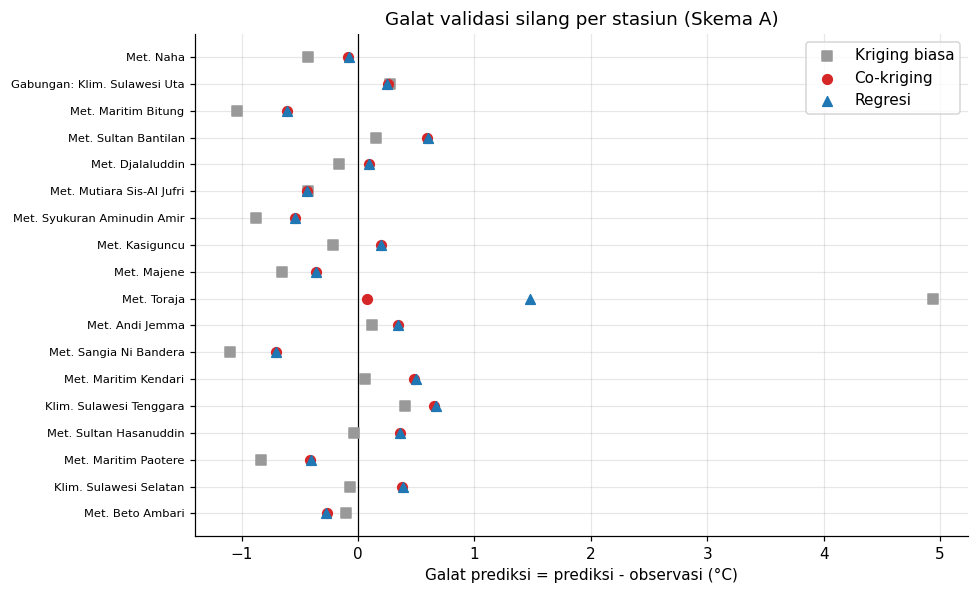

Galat terstandar co-kriging: rata-rata = -0.00, simpangan baku = 0.99 | 100% berada dalam ±2


In [22]:
short = dfa.Nama.str.replace("Stasiun ", "").str.replace("Meteorologi ", "Met. ").str.replace("Klimatologi ", "Klim. ").str.slice(0, 28)
err = pd.DataFrame({"OK": predA["OK"] - obs, "COK": predA["COK"] - obs, "REG": predA["REG"] - obs}, index=short)
fig, ax = plt.subplots(figsize=(9, 5.5)); yy = np.arange(len(err))
for k, c, mk in [("OK", "#999999", "s"), ("COK", "#d62728", "o"), ("REG", "#1f77b4", "^")]:
    ax.scatter(err[k], yy, c=c, marker=mk, label={"OK": "Kriging biasa", "COK": "Co-kriging", "REG": "Regresi"}[k], s=40, zorder=3)
ax.axvline(0, color="k", lw=.8); ax.set_yticks(yy); ax.set_yticklabels(err.index, fontsize=7.5); ax.invert_yaxis()
ax.set_xlabel("Galat prediksi = prediksi - observasi (°C)"); ax.legend(); ax.set_title("Galat validasi silang per stasiun (Skema A)")
plt.tight_layout(); plt.savefig("hasil/07_galat_per_stasiun.png", dpi=200); plt.show()

zc = (predA["COK"] - obs) / np.sqrt(np.maximum(varA["COK"], 1e-9))
print(f"Galat terstandar co-kriging: rata-rata = {zc.mean():.2f}, simpangan baku = {zc.std(ddof=1):.2f} | {np.mean(np.abs(zc)<2)*100:.0f}% berada dalam ±2")

### 8.3 Skema B: variogram dicocokkan ulang di setiap lipatan (lebih ketat)

Proses ini agak lama (mencocokkan LMC berulang kali), biasanya sekitar 1 menit.

In [23]:
t0 = time.time()
predB, varB = loo_nested(xy, Z, lmc["kind"], N_LAGS)
tabB = metrics_table(obs, predB, varB)
print(f"Validasi silang Skema B (variogram dicocokkan ulang per lipatan) | waktu {time.time()-t0:.0f} detik"); tabB.round(3)

Validasi silang Skema B (variogram dicocokkan ulang per lipatan) | waktu 111 detik


,R2_CV,r2_Pearson,RMSE,MAE,ME,MSDR
Ordinary Kriging (suhu saja),-0.225,0.035,1.334,0.754,-0.106,6.626
Ordinary Co-Kriging (suhu + elevasi),0.641,0.841,0.722,0.484,0.028,1.945
Regresi linear suhu ~ elevasi,0.791,0.860,0.551,0.461,0.080,NaN


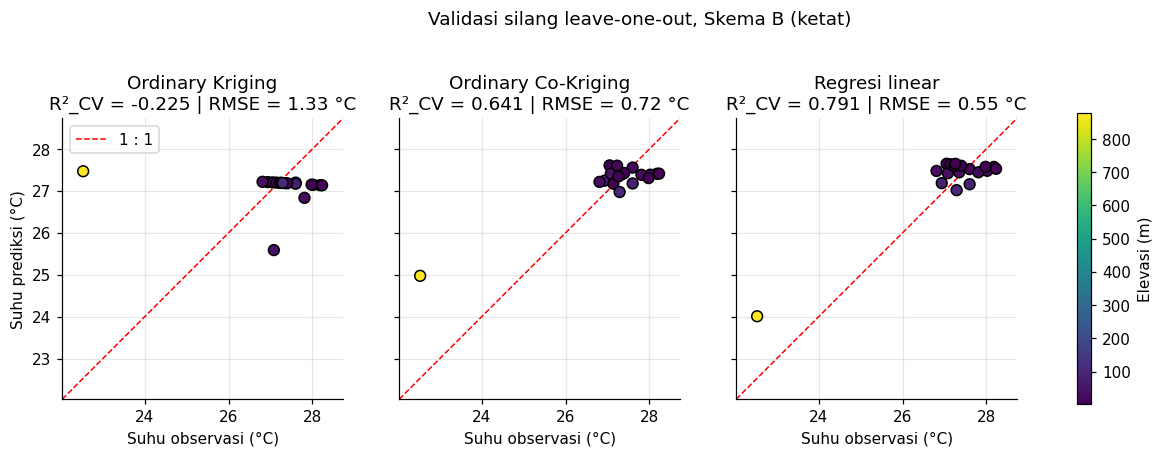

In [24]:
plot_cv(predB, "Validasi silang leave-one-out, Skema B (ketat)", "hasil/08_cv_skemaB.png")

### 8.4 Uji ketahanan: dari mana R² berasal?

Tiga pertanyaan diuji:

1. **Apakah manfaat ko-kriging benar berasal dari elevasi di lokasi target?** Kita bandingkan dengan versi di mana elevasi di stasiun yang diuji ikut dibuang.
2. **Seberapa besar R² bergantung pada satu stasiun (Toraja)?** Kita hitung R² hanya pada stasiun dataran rendah (< 500 m), sementara Toraja tetap dipakai sebagai data latih.
3. **Apa efek Stasiun Manado?** Lihat Bagian 8.5.

In [25]:
low = Z[:, 1] < 500
predS, varS = loo_fixed(xy, Z, lmc, uni, secondary_at_target=False)

robust = pd.DataFrame({
    "R2_CV semua stasiun (Skema A)":            {"Kriging biasa": cv_metrics(obs, predA["OK"])["R2_CV"],  "Co-kriging": cv_metrics(obs, predA["COK"])["R2_CV"],  "Regresi": cv_metrics(obs, predA["REG"])["R2_CV"]},
    "R2_CV semua stasiun (Skema B)":            {"Kriging biasa": cv_metrics(obs, predB["OK"])["R2_CV"],  "Co-kriging": cv_metrics(obs, predB["COK"])["R2_CV"],  "Regresi": cv_metrics(obs, predB["REG"])["R2_CV"]},
    "Co-kriging TANPA elevasi di target (A)":   {"Kriging biasa": np.nan, "Co-kriging": cv_metrics(obs, predS["COK"])["R2_CV"], "Regresi": np.nan},
    "R2_CV hanya stasiun < 500 m (A)":          {"Kriging biasa": cv_metrics(obs[low], predA["OK"][low])["R2_CV"], "Co-kriging": cv_metrics(obs[low], predA["COK"][low])["R2_CV"], "Regresi": cv_metrics(obs[low], predA["REG"][low])["R2_CV"]},
    "R2_CV hanya stasiun < 500 m (B)":          {"Kriging biasa": cv_metrics(obs[low], predB["OK"][low])["R2_CV"], "Co-kriging": cv_metrics(obs[low], predB["COK"][low])["R2_CV"], "Regresi": cv_metrics(obs[low], predB["REG"][low])["R2_CV"]},
}).T
robust.round(3)

,Kriging biasa,Co-kriging,Regresi
R2_CV semua stasiun (Skema A),-0.121,0.876,0.791
R2_CV semua stasiun (Skema B),-0.225,0.641,0.791
Co-kriging TANPA elevasi di target (A),NaN,-0.121,NaN
R2_CV hanya stasiun < 500 m (A),-0.583,-0.042,-0.058
R2_CV hanya stasiun < 500 m (B),-1.458,-0.100,-0.058


### 8.5 Analisis sensitivitas: model, jumlah lag, dan keputusan tentang Manado

Kalau hasil berubah drastis saat pilihan analisis digeser sedikit, hasil itu tidak kokoh. Tabel berikut membandingkan beberapa konfigurasi (Skema A).

In [26]:
def evaluate(drop_ids, kind, n_lags, n_starts=10):
    d, _ = build_analysis_frame(df_all, drop_ids, MERGE_TOL_KM)
    xy_, Z_ = d[["X", "Y"]].values, d[["Tavg", "Elev"]].values
    md_ = cdist(xy_, xy_).max(); ct = md_ / 2
    ev_ = emp_variograms(xy_, Z_, np.linspace(0, ct, n_lags + 1))
    l_ = fit_lmc(ev_, kind, ct * .6, (ct * .1, md_), n_starts=n_starts); u_ = fit_univariate(ev_, kind, (ct * .1, md_))
    p_, v_ = loo_fixed(xy_, Z_, l_, u_); o_ = Z_[:, 0]
    return {"n": len(d), "range_km": l_["a"], "R2 OK": cv_metrics(o_, p_["OK"])["R2_CV"], "R2 Co-kriging": cv_metrics(o_, p_["COK"])["R2_CV"],
            "R2 Regresi": cv_metrics(o_, p_["REG"])["R2_CV"], "RMSE Co-kriging": cv_metrics(o_, p_["COK"])["RMSE"]}

rows, labels = [], []
for kd in ["spherical", "exponential", "gaussian"]:
    for nl in sorted({5, N_LAGS, 9}):
        rows.append(evaluate(DROP_IDS, kd, nl)); labels.append(f"{kd}, {nl} lag, Manado {'dikeluarkan' if DROP_IDS else 'ikut'}")
rows.append(evaluate([], lmc["kind"], N_LAGS)); labels.append(f"{lmc['kind']}, {N_LAGS} lag, SEMUA stasiun (Manado ikut)")
sens = pd.DataFrame(rows, index=labels); sens.round(3)

,n,range_km,R2 OK,R2 Co-kriging,R2 Regresi,RMSE Co-kriging
"spherical, 5 lag, Manado dikeluarkan",18,60.089,-0.121,0.867,0.791,0.439
"spherical, 7 lag, Manado dikeluarkan",18,62.808,-0.121,0.876,0.791,0.425
"spherical, 9 lag, Manado dikeluarkan",18,105.488,-0.157,0.879,0.791,0.418
"exponential, 5 lag, Manado dikeluarkan",18,59.343,-0.121,0.876,0.791,0.425
"exponential, 7 lag, Manado dikeluarkan",18,59.343,-0.121,0.876,0.791,0.425
"exponential, 9 lag, Manado dikeluarkan",18,87.820,-0.143,0.879,0.791,0.419
"gaussian, 5 lag, Manado dikeluarkan",18,59.343,-0.121,0.875,0.791,0.426
"gaussian, 7 lag, Manado dikeluarkan",18,59.343,-0.121,0.876,0.791,0.424
"gaussian, 9 lag, Manado dikeluarkan",18,74.948,-0.177,0.879,0.791,0.419
"spherical, 7 lag, SEMUA stasiun (Manado ikut)",19,59.343,-0.114,0.530,-2.848,1.041


**Cara membaca.** Perhatikan tiga hal: (1) apakah R² co-kriging stabil antar model dan jumlah lag; (2) apakah co-kriging konsisten mengungguli kriging biasa; (3) apa yang terjadi kalau data Manado yang diduga salah tidak dikeluarkan (baris terakhir). Baris terakhir sekaligus alasan kuat mengapa pemeriksaan kualitas data di Bagian 2 penting: satu nilai yang salah dapat menurunkan R² secara nyata.

### 8.6 Ringkasan interpretasi hasil validasi

In [27]:
cA, cB = tabA.loc["Ordinary Co-Kriging (suhu + elevasi)"], tabB.loc["Ordinary Co-Kriging (suhu + elevasi)"]
oA, rA = tabA.loc["Ordinary Kriging (suhu saja)"], tabA.loc["Regresi linear suhu ~ elevasi"]
print("RINGKASAN HASIL")
print("-" * 78)
print(f"Data analisis           : {len(dfa)} lokasi | korelasi Pearson suhu-elevasi r = {lr.rvalue:.3f} | {lr.slope*1000:.2f} °C per km")
print(f"Model variogram (LMC)   : {lmc['kind']}, range = {lmc['a']:.0f} km")
print(f"Kriging biasa           : R2_CV = {oA.R2_CV:.3f}  RMSE = {oA.RMSE:.3f} °C")
print(f"Co-kriging Skema A      : R2_CV = {cA.R2_CV:.3f}  RMSE = {cA.RMSE:.3f} °C  (r2 Pearson = {cA.r2_Pearson:.3f})")
print(f"Co-kriging Skema B      : R2_CV = {cB.R2_CV:.3f}  RMSE = {cB.RMSE:.3f} °C  (r2 Pearson = {cB.r2_Pearson:.3f})")
print(f"Regresi linear          : R2_CV = {rA.R2_CV:.3f}  RMSE = {rA.RMSE:.3f} °C")
print(f"Co-kriging, stasiun <500 m saja : R2_CV = {robust.iloc[3]['Co-kriging']:.3f} (A) | {robust.iloc[4]['Co-kriging']:.3f} (B)")
print("-" * 78)

RINGKASAN HASIL
------------------------------------------------------------------------------
Data analisis           : 18 lokasi | korelasi Pearson suhu-elevasi r = -0.943 | -5.77 °C per km
Model variogram (LMC)   : spherical, range = 59 km
Kriging biasa           : R2_CV = -0.121  RMSE = 1.276 °C
Co-kriging Skema A      : R2_CV = 0.876  RMSE = 0.424 °C  (r2 Pearson = 0.876)
Co-kriging Skema B      : R2_CV = 0.641  RMSE = 0.722 °C  (r2 Pearson = 0.841)
Regresi linear          : R2_CV = 0.791  RMSE = 0.551 °C
Co-kriging, stasiun <500 m saja : R2_CV = -0.042 (A) | -0.100 (B)
------------------------------------------------------------------------------


**Yang perlu kamu pahami dan tulis di laporan:**

1. **Co-kriging jauh lebih baik daripada kriging biasa.** Kriging biasa hanya memakai suhu, dan karena suhu tidak punya struktur jarak, prediksinya nyaris sama dengan rata-rata sehingga R²<sub>CV</sub> mendekati nol atau negatif. Co-kriging memasukkan elevasi dan R²<sub>CV</sub>-nya naik tajam.
2. **Sumber peningkatannya jelas:** baris "Co-kriging TANPA elevasi di target" di Bagian 8.4 kembali persis ke performa kriging biasa. Jadi manfaat ko-kriging di sini murni datang dari korelasi kuat suhu-elevasi di lokasi yang sama.
3. **Jangan menulis bahwa co-kriging mengalahkan regresi linear.** Di Skema A co-kriging tampak lebih tinggi, tetapi perbandingan itu tidak adil: regresi menghitung ulang kemiringannya tanpa stasiun yang diuji (jadi setara Skema B), sedangkan Skema A memakai parameter yang sudah "melihat" semua stasiun termasuk Toraja. Bandingkan regresi dengan **Skema B**. Di data ini regresi sederhana sama baik atau lebih baik daripada Skema B. Yang jujur untuk ditulis: elevasi adalah kunci prediksi, dan ko-kriging tidak memberi tambahan nyata di atas regresi karena tidak ada struktur jarak yang bisa dimanfaatkan.
4. **R² dipengaruhi kuat oleh Toraja.** Pada stasiun dataran rendah saja, R² nol atau negatif untuk semua metode, karena variasi suhu di antara stasiun pesisir kecil dan tidak dijelaskan elevasi (semuanya rendah). Ini keterbatasan data, bukan kesalahan metode.
5. **Skema B lebih rendah daripada Skema A** karena tidak ada "bocoran" informasi Toraja saat membentuk variogram. Perhatikan juga MSDR pada Skema B yang jauh di atas 1: varians kriging meremehkan galat sebenarnya, jadi ketidakpastian yang dilaporkan terlalu optimistis.
6. **Cara menulis R² di laporan:** laporkan rentang, misalnya "R²<sub>CV</sub> berkisar dari nilai Skema B sampai nilai Skema A", sebut bahwa nilainya ditopang satu stasiun dataran tinggi, dan tampilkan uji ketahanan di Bagian 8.4. Angka yang jujur dan disertai catatan lebih kuat di sidang daripada satu angka tinggi tanpa penjelasan.

## 9. Peta prediksi suhu

Untuk membuat peta, kita perlu elevasi di setiap titik grid. Sel di bawah mengambil elevasi SRTM 30 m lewat layanan gratis **OpenTopoData** (`api.opentopodata.org`). Di laut layanan mengembalikan nilai kosong, jadi sekaligus berfungsi sebagai **masker daratan**. Prosesnya sekitar 2 sampai 3 menit dan membutuhkan koneksi internet.

Kalau layanan gagal diakses, kamu bisa mengunggah file CSV berisi kolom `lon,lat,elev` (misalnya hasil ekstraksi SRTM/DEMNAS dari QGIS), dan sel akan memakainya.

> Peta di bawah adalah prediksi di **titik-titik grid** (resolusi `GRID_RES_DEG`), bukan rata-rata per area. Puncak pegunungan yang lebih sempit dari jarak grid tidak tertangkap.

In [28]:
GRID_RES_DEG = 0.10
LON_RNG, LAT_RNG = (118.6, 125.6), (-6.0, 2.0)     # kotak pembatas Pulau Sulawesi bagian daratan utama
ELEV_DATASET = "srtm30m"
GRID_CACHE = "hasil/grid_elevasi.csv"

lons = np.round(np.arange(LON_RNG[0], LON_RNG[1] + 1e-9, GRID_RES_DEG), 5)
lats = np.round(np.arange(LAT_RNG[0], LAT_RNG[1] + 1e-9, GRID_RES_DEG), 5)
LON, LAT = np.meshgrid(lons, lats)
print(f"Grid {LON.shape[1]} x {LON.shape[0]} = {LON.size} titik")

def fetch_elevation(lat, lon, dataset=ELEV_DATASET, batch=50, pause=1.1):
    import requests
    out = np.full(len(lat), np.nan)
    for s in range(0, len(lat), batch):
        loc = "|".join(f"{a:.5f},{b:.5f}" for a, b in zip(lat[s:s + batch], lon[s:s + batch]))
        for attempt in range(5):
            r = requests.get(f"https://api.opentopodata.org/v1/{dataset}", params={"locations": loc}, timeout=60)
            if r.status_code == 200: break
            time.sleep(2 + 2 * attempt)
        else:
            raise RuntimeError(f"API gagal (status {r.status_code})")
        res = r.json()["results"]
        out[s:s + len(res)] = [np.nan if x["elevation"] is None else x["elevation"] for x in res]
        time.sleep(pause)
    return out

grid_ok, elev_g = False, None
if os.path.exists(GRID_CACHE):
    c = pd.read_csv(GRID_CACHE)
    if len(c) == LON.size: elev_g = c["elev"].values; grid_ok = True; print("Memakai cache elevasi grid.")
if not grid_ok:
    try:
        print("Mengambil elevasi SRTM dari OpenTopoData ...")
        elev_g = fetch_elevation(LAT.ravel(), LON.ravel())
        pd.DataFrame({"lon": LON.ravel(), "lat": LAT.ravel(), "elev": elev_g}).to_csv(GRID_CACHE, index=False); grid_ok = True
    except Exception as e:
        print("Gagal mengambil elevasi otomatis:", e)
        try:
            from google.colab import files
            print("Unggah CSV dengan kolom lon,lat,elev (grid harus sama dengan di atas), atau batalkan untuk melewati bagian peta.")
            up = files.upload()
            if up:
                c = pd.read_csv(io.BytesIO(list(up.values())[0]))
                if len(c) == LON.size: elev_g = c["elev"].values; grid_ok = True
                else: print(f"Jumlah baris ({len(c)}) tidak sama dengan jumlah titik grid ({LON.size}).")
        except Exception:
            pass
print("Elevasi grid siap." if grid_ok else "Bagian peta dilewati (tidak ada elevasi grid).")

Grid 71 x 81 = 5751 titik
Mengambil elevasi SRTM dari OpenTopoData ...
Elevasi grid siap.


In [29]:
if grid_ok:
    elev_g = np.where(np.isfinite(elev_g), np.clip(elev_g, 0, None), np.nan)
    gx, gy = Transformer.from_crs(CRS_GEO, CRS_PROJ, always_xy=True).transform(LON.ravel(), LAT.ravel()); gx, gy = gx / 1000, gy / 1000
    land = np.where(np.isfinite(elev_g))[0]
    print(f"Titik daratan yang diprediksi: {len(land)} dari {LON.size}")
    pc, sc_, po = (np.full(LON.size, np.nan) for _ in range(3))
    t0 = time.time()
    for k in land:
        x0 = np.array([gx[k], gy[k]])
        p, v = predict_cok(x0, xy, Z[:, 0], xy, Z[:, 1], lmc, elev_g[k]); pc[k], sc_[k] = p, np.sqrt(v)
        po[k] = ordinary_kriging_point(x0, xy, Z[:, 0], uni)[0]
    print(f"Selesai dalam {time.time()-t0:.0f} detik")
    shp = LON.shape
    dist_near = np.full(LON.size, np.nan)
    dist_near[land] = cdist(np.column_stack([gx[land], gy[land]]), xy).min(axis=1)
    E_max = Z[:, 1].max(); frac_extrap = np.mean(elev_g[land] > E_max) * 100
    print(f"Simpangan baku kriging: {np.nanmin(sc_):.3f} s.d. {np.nanmax(sc_):.3f} °C (hampir konstan, lihat catatan 9.1)")
    print(f"Elevasi stasiun tertinggi = {E_max:.0f} m | {frac_extrap:.1f}% titik daratan grid berada di atasnya (ekstrapolasi elevasi)")
    pd.DataFrame({"lon": LON.ravel(), "lat": LAT.ravel(), "elev_m": elev_g, "T_cokriging": pc, "SD_cokriging": sc_,
                  "T_kriging_biasa": po, "jarak_stasiun_terdekat_km": dist_near}).dropna(subset=["elev_m"]).to_csv("hasil/prediksi_grid.csv", index=False)

Titik daratan yang diprediksi: 4891 dari 5751
Selesai dalam 2 detik
Simpangan baku kriging: 0.438 s.d. 0.439 °C (hampir konstan, lihat catatan 9.1)
Elevasi stasiun tertinggi = 878 m | 7.4% titik daratan grid berada di atasnya (ekstrapolasi elevasi)


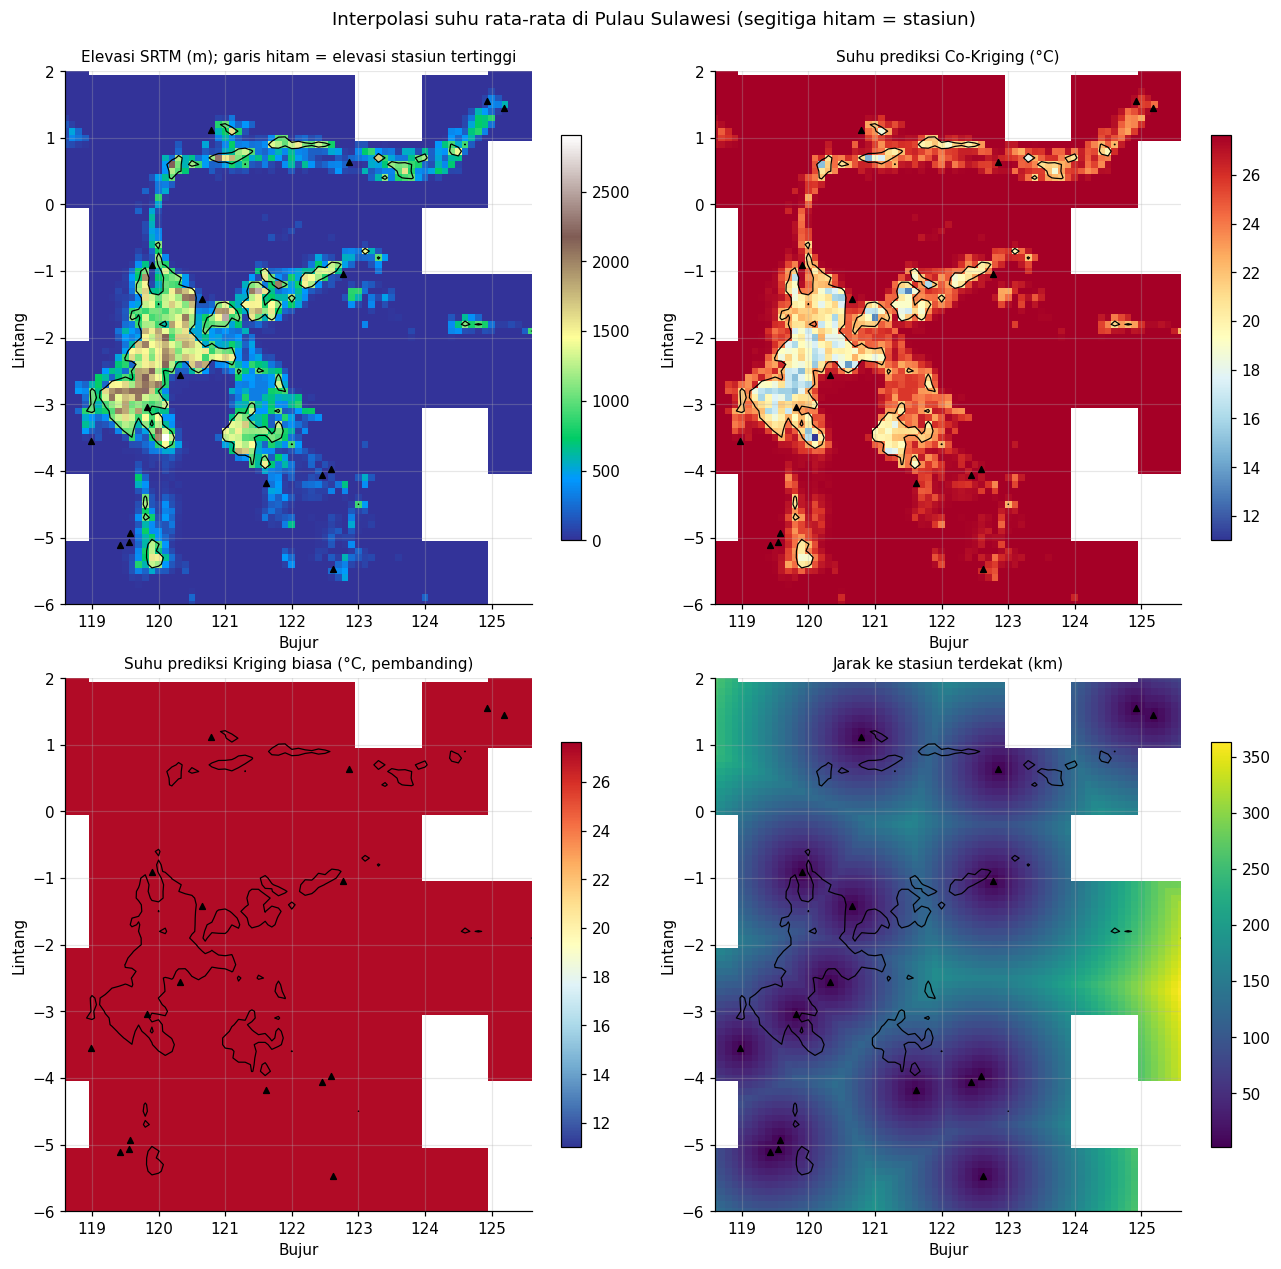

Kisaran suhu prediksi co-kriging: 11.0 s.d. 27.6 °C


In [31]:
if grid_ok:
    fig, ax = plt.subplots(2, 2, figsize=(12, 11.5))
    panels = [(elev_g, "Elevasi SRTM (m); garis hitam = elevasi stasiun tertinggi", "terrain", None),
              (pc, "Suhu prediksi Co-Kriging (°C)", "RdYlBu_r", None),
              (po, "Suhu prediksi Kriging biasa (°C, pembanding)", "RdYlBu_r", (np.nanmin(pc), np.nanmax(pc))),
              (dist_near, "Jarak ke stasiun terdekat (km)", "viridis", None)]
    for a, (arr, ttl, cm, vr) in zip(ax.ravel(), panels):
        kw = {} if vr is None else {"vmin": vr[0], "vmax": vr[1]}
        m = a.pcolormesh(LON, LAT, arr.reshape(shp), cmap=cm, shading="auto", **kw)
        if np.nanmax(elev_g) > E_max: a.contour(LON, LAT, np.nan_to_num(elev_g, nan=0).reshape(shp), levels=[E_max], colors="k", linewidths=.8)
        a.scatter(dfa.Lon, dfa.Lat, c="k", s=14, marker="^", zorder=5); a.set_title(ttl, fontsize=10); a.set_aspect("equal")
        a.set_xlim(LON_RNG); a.set_ylim(LAT_RNG); a.set_xlabel("Bujur"); a.set_ylabel("Lintang"); plt.colorbar(m, ax=a, shrink=.75)
    fig.suptitle("Interpolasi suhu rata-rata di Pulau Sulawesi (segitiga hitam = stasiun)", y=0.995)
    plt.tight_layout(); plt.savefig("hasil/09_peta_prediksi.png", dpi=200); plt.show()
    print(f"Kisaran suhu prediksi co-kriging: {np.nanmin(pc):.1f} s.d. {np.nanmax(pc):.1f} °C")

### 9.1 Membaca peta (dan batasannya)

* **Peta co-kriging** mengikuti relief: pesisir hangat, pegunungan dingin. Pola ini datang dari **elevasi**, bukan dari jarak antar stasiun.
* **Peta kriging biasa** (pembanding) seragam. Tanpa elevasi, ia tidak bisa menangkap pegunungan.
* **Peta jarak ke stasiun terdekat** menunjukkan bagian pulau yang jauh dari data.
* **Simpangan baku kriging tidak ditampilkan sebagai peta** karena pada data ini nilainya hampir konstan (dicetak di atas). Sebabnya: tanpa struktur jarak, varians kriging tidak bertambah saat menjauhi stasiun. Akibatnya, simpangan baku **tidak menangkap risiko ekstrapolasi** yang sebenarnya, yaitu risiko di ketinggian yang tidak pernah diamati stasiun.
* **Ekstrapolasi elevasi.** Hubungan suhu-elevasi hanya dipelajari sampai elevasi stasiun tertinggi (garis hitam di panel elevasi). Di atas garis itu, prediksi menerapkan laju penurunan suhu yang sama dan **tidak terverifikasi**. Sulawesi punya puncak jauh di atas 878 m, jadi suhu prediksi di pegunungan tinggi harus diperlakukan sebagai perkiraan kasar.
* Stasiun **Naha** (3,69°LU) tampaknya berada di Pulau Sangihe, di luar kotak peta pulau utama. Ia tetap dipakai sebagai data, hanya tidak tampak di peta.

## 10. Kesimpulan, keterbatasan, dan saran

### 10.1 Kesimpulan

1. **Kualitas data.** Kolom UTM di file bercampur dua zona, sehingga koordinat dihitung ulang dari lintang/bujur ke UTM 51S. Satu stasiun (Manado 97010) memiliki suhu yang tidak wajar secara fisik dan dikeluarkan, dan dua stasiun yang berimpit digabung.
2. **Hubungan variabel.** Suhu dan elevasi berkorelasi negatif sangat kuat menurut Pearson, dengan laju penurunan sekitar 6 °C per km yang konsisten dengan teori atmosfer, tetapi kekuatan itu ditopang satu stasiun dataran tinggi.
3. **Struktur spasial.** Variogram suhu hampir datar (efek nugget murni): variasi suhu ditentukan oleh elevasi, bukan oleh jarak. Karena itu kriging biasa tidak berguna di sini.
4. **Kinerja.** Ko-kriging dengan elevasi kolokasi jauh mengungguli kriging biasa. R²<sub>CV</sub> dilaporkan pada dua skema validasi (lihat 8.6), dan ko-kriging tidak terbukti lebih baik daripada regresi elevasi sederhana.
5. **Peta.** Peta suhu mengikuti relief, dan hanya sahih pada rentang elevasi yang diamati stasiun.

### 10.2 Keterbatasan (tulis di laporan)

* **Jumlah data kecil (sekitar 18 lokasi).** Estimasi variogram, terutama range dan sill, tidak stabil.
* **Hanya satu stasiun dataran tinggi.** R² sangat bergantung pada Toraja. Pada stasiun pesisir saja, elevasi tidak menjelaskan variasi suhu yang tersisa.
* **Ko-kriging setara dengan regresi elevasi di sini.** Keunggulan sejatinya (memanfaatkan struktur jarak) belum terlihat karena tidak ada struktur jarak yang kuat.
* **Periode rata-rata suhu tidak diketahui.** Kalau periodenya berbeda antar stasiun, itu menambah galat.
* **Peta berbasis elevasi grid titik**, bukan rata-rata area.

### 10.3 Saran untuk memperbaiki hasil (secara sah)

1. **Periksa ulang nilai Manado ke sumber BMKG.** Kalau ada nilai yang benar, masukkan dan analisis ulang dengan `DROP_IDS = []`.
2. **Tambah stasiun, terutama dataran menengah dan tinggi** (300 sampai 1500 m): stasiun BMKG atau pos pengamatan lain, atau titik ekstraksi suhu dari ERA5-Land. Ini paling efektif menstabilkan variogram dan membuat R² lebih bisa dipercaya.
3. **Gunakan periode rata-rata yang sama untuk semua stasiun** (misalnya rata-rata 2021 sampai 2025).
4. **Pertimbangkan Kriging with External Drift atau Regression Kriging** sebagai pembanding lanjutan, terutama bila stasiun bertambah.
5. Kalau ada variabel sekunder yang tersedia rapat (DEM), ko-kriging kolokasi seperti di Bagian 9 adalah cara yang tepat memanfaatkannya.

### 10.4 Ekspor hasil

In [ ]:
cv_out = dfa[["Station_ID", "Nama", "Lon", "Lat", "Tavg", "Elev"]].copy()
for k, nm in [("OK", "pred_OK_A"), ("COK", "pred_COK_A"), ("REG", "pred_REG_A")]: cv_out[nm] = predA[k]
for k, nm in [("OK", "pred_OK_B"), ("COK", "pred_COK_B"), ("REG", "pred_REG_B")]: cv_out[nm] = predB[k]
cv_out["sd_COK_A"] = np.sqrt(varA["COK"]); cv_out.round(4).to_csv("hasil/validasi_silang_per_stasiun.csv", index=False)
tabA.round(4).to_csv("hasil/metrik_skemaA.csv"); tabB.round(4).to_csv("hasil/metrik_skemaB.csv")
robust.round(4).to_csv("hasil/uji_ketahanan.csv"); sens.round(4).to_csv("hasil/uji_sensitivitas.csv")
pd.DataFrame({"parameter": ["model", "range_km", "B11", "B22", "B12", "N11", "N22", "N12"],
              "nilai": [lmc["kind"], lmc["a"], lmc["B"][0, 0], lmc["B"][1, 1], lmc["B"][0, 1], lmc["N"][0, 0], lmc["N"][1, 1], lmc["N"][0, 1]]}).to_csv("hasil/parameter_LMC.csv", index=False)
print("File di folder hasil/:"); print("\n".join(sorted(os.listdir("hasil"))))
try:
    import shutil; from google.colab import files
    shutil.make_archive("hasil_cokriging", "zip", "hasil"); files.download("hasil_cokriging.zip")
except Exception:
    pass